# E70 · Compositional data: parts of a whole (Dirichlet, logistic-normal and Dirichlet-multinomial models)

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: (1) Aitchison's **Arctic lake sediments** (sand / silt / clay percentages of 39 samples and the water depth each came from; Aitchison 1986, Data 5, via the R package compositions); (2) the **2024 UK general election in England**: votes for every candidate in the 543 English constituencies (UK Parliament election results service, Open Parliament Licence), grouped into Labour, Conservative, Reform UK, Liberal Democrat, Green and everyone else. A simulated re-run of the election model is used once as a known-truth check (labelled) |
| **You will learn** | What makes data **compositional** (only ratios carry information) · why ordinary regression on shares fails: **predictions outside the simplex** and **spurious correlation from closure** · **Aitchison geometry**: ALR, CLR and ILR log-ratios, and why the choice of **reference part** does not matter for a full-covariance model · **Dirichlet regression** in the mean-precision parameterisation and the variance structure it imposes (only negative correlations; small parts erratic on the log scale) · posterior predictive checks aimed at that structure, which the Dirichlet **cannot pass** · the **logistic-normal** model (MvNormal on log-ratios with an **LKJ** covariance) and a version whose **scatter changes with a covariate** · comparing a Dirichlet and a logistic-normal by LOO **on the same scale** (the log-ratio Jacobian) · **counts, not shares**: why a multinomial is absurdly overconfident for votes, the **Dirichlet-multinomial** and its "effective sample size" · **zeros**: why log-ratios break, why the usual "add half a vote" is harmful, and how a **structural zero** (a party that did not stand) is handled exactly by dropping that part · **partial pooling** of regional compositions · reference-free (CLR) covariate effects · predicted compositions on a **hand-drawn ternary plot** · turning a composition model into **seat counts and win probabilities**, and a seat-level check that every model here fails (and why) |

## Parts of a whole

A lot of data are **shares of a total**: the sand, silt and clay in a sediment sample, the vote
split in a constituency, the fraction of a household budget spent on food, housing and
transport, the cell types in a tissue sample, the species in a microbiome read. The total is
either fixed by design (percentages sum to 100) or uninformative (a larger sediment sample does
not have "more sand" in any interesting sense). What carries the information is the **relative
size of the parts**.

This has two consequences that trip up ordinary methods:

* the data live on the **simplex** (non-negative parts summing to one), so a model for them
  must never predict a negative share or shares summing to more than one;
* the parts are **not free to vary independently**: if one share goes up, others must go down.
  Correlations between raw shares are partly an artefact of this constraint ("closure"), and
  they change if you drop a part and renormalise.

John Aitchison's answer (1982, 1986) was to analyse **log-ratios** of parts, which are
unconstrained real numbers and do not care about the total. This notebook builds the
Bayesian toolkit on two real datasets:

1. **Sediments** (3 parts, 39 samples, one covariate): the basics - geometry, Dirichlet
   regression, a check it fails, and logistic-normal models that pass it.
2. **Votes** (6 parts, 542 constituencies, 9 regions): counts rather than shares, zeros,
   partial pooling, and a decision: what does the composition model say about who wins seats?

## The plan

1. Sediment data: why ordinary regression on shares fails
2. Log-ratio geometry: ALR, CLR, ILR and the reference part
3. Dirichlet regression, and a predictive check it cannot pass
4. Logistic-normal models, LOO on the same scale, and predicted compositions
5. Votes as counts: data, zeros and the model family
6. Multinomial vs Dirichlet-multinomial: how many "votes" is a constituency worth?
7. The logistic-normal for votes: correlation, a known-truth check
8. From compositions to seats: turnout effects and win probabilities

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from matplotlib.lines import Line2D
from scipy import special

from pymc_challenges import data

RANDOM_SEED = 70
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")  # NaN r_hat of constants
warnings.filterwarnings("ignore", message="Estimated shape parameter of Pareto")  # we print k-hat
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def q(x, probs=(0.05, 0.5, 0.95), axis=None):
    """Posterior quantiles, rounded for printing."""
    return np.round(np.quantile(x, probs, axis=axis), 2)


def draws(idata, name, group="posterior"):
    """All draws of one variable as a NumPy array with chains stacked: (samples, ...)."""
    v = idata[group][name].to_numpy()
    return v.reshape((-1,) + v.shape[2:])


def closure(x):
    x = np.asarray(x, float)
    return x / x.sum(axis=-1, keepdims=True)


def fit_report(idata, names, t0):
    """One line of sampler diagnostics."""
    r = max(float(az.rhat(idata, var_names=[v]).to_dataset()[v].max()) for v in names)
    e = min(float(az.ess(idata, var_names=[v]).to_dataset()[v].min()) for v in names)
    print(f"{time.time() - t0:.0f} s, max r_hat {r:.3f}, min bulk ESS {e:.0f}, "
          f"divergences {int(idata.sample_stats['diverging'].sum())}, "
          f"tuning steps {idata.posterior.attrs.get('tuning_steps')}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


### A ternary plot, drawn by hand

A three-part composition is a point in an equilateral triangle: each corner is 100% of one
part and the distance from the opposite side is that part's share. We draw the axes ourselves
with matplotlib (no extra dependency): corner order is (bottom-left, bottom-right, top).

In [2]:
SQ3 = np.sqrt(3) / 2


def tern_xy(p):
    """Composition(s) (..., 3) -> x, y in the triangle; parts = (bottom-left, bottom-right, top)."""
    p = closure(p)
    return p[..., 1] + 0.5 * p[..., 2], SQ3 * p[..., 2]


def tern_axes(ax, labels, grid=(0.2, 0.4, 0.6, 0.8)):
    """Triangle, 20% grid lines for every part, corner labels."""
    ax.plot([0, 1, 0.5, 0], [0, 0, SQ3, 0], color="k", lw=1)
    for g in grid:
        for k in range(3):
            a, b = np.zeros(3), np.zeros(3)
            a[k], b[k] = g, g
            a[(k + 1) % 3], b[(k + 2) % 3] = 1 - g, 1 - g
            ax.plot(*tern_xy(np.stack([a, b])), color="0.85", lw=0.6, zorder=0)
    for (x, y), lab, ha, va in zip([(0, 0), (1, 0), (0.5, SQ3)], labels,
                                   ["right", "left", "center"], ["top", "top", "bottom"]):
        ax.annotate(lab, (x, y), ha=ha, va=va, fontsize=10, fontweight="bold",
                    xytext=(0, -4 if va == "top" else 4), textcoords="offset points")
    ax.set_aspect("equal")
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.08, SQ3 + 0.06)
    ax.axis("off")

---
# 1 · Sediment data: why ordinary regression on shares fails

## 1.1 · The data

In [3]:
data.describe("arctic_lake_sediment")
lake = data.load("arctic_lake_sediment")
PART3 = ["sand", "silt", "clay"]
print("row sums before closure:", q(lake[PART3].sum(axis=1), (0, 0.5, 1)))
X3 = closure(lake[PART3].to_numpy())          # shares summing to exactly 1
depth = lake["depth"].to_numpy()
xd = np.log2(depth / 40)                        # covariate: doublings of depth relative to 40 m
lake.describe().round(1)

arctic_lake_sediment: Sand, silt and clay percentages of 39 sediment samples from an Arctic lake, with the water depth (m) at which each was taken. Columns: sample (1-39), sand, silt, clay (percent; rows sum to 100 up to rounding, 99.7-100.5), depth (10.4-103.7 m).
  source: Aitchison (1986), The Statistical Analysis of Compositional Data, Data 5 (file ARCTIC.DAT of his CODA package); distributed as `ArcticLake` in the CRAN package compositions (van den Boogaart, Tolosana-Delgado & Bren; GPL >= 2; the URL). CONVERTED from the .rda with R (values unchanged, a sample index added) - keep the CSV in data/.
  url:    https://raw.githubusercontent.com/cran/compositions/master/data/ArcticLake.rda
row sums before closure: [ 99.7 100.  100.5]


,sample,sand,silt,clay,depth
count,39.0,39.0,39.0,39.0,39.0
mean,20.0,24.2,45.7,30.1,48.0
std,11.4,24.5,10.1,17.2,28.1
min,1.0,2.0,19.5,0.6,10.4
25%,10.5,6.4,42.3,16.0,22.2
50%,20.0,10.8,48.0,34.9,47.0
75%,29.5,40.7,52.4,45.4,71.4
max,39.0,77.5,69.8,52.2,103.7


Thirty-nine samples of lake-bed sediment, each split into three grain-size classes (sand is
coarsest, clay finest), and the water depth at which it was taken. The percentages are
rounded, so rows sum to 99.7-100.5; we **close** them (divide by the row sum), which is the
only thing we will ever do with the total. Our covariate is $\log_2(\text{depth}/40\,\text{m})$,
so a coefficient means "per doubling of depth", and 0 is a depth in the middle of the data.

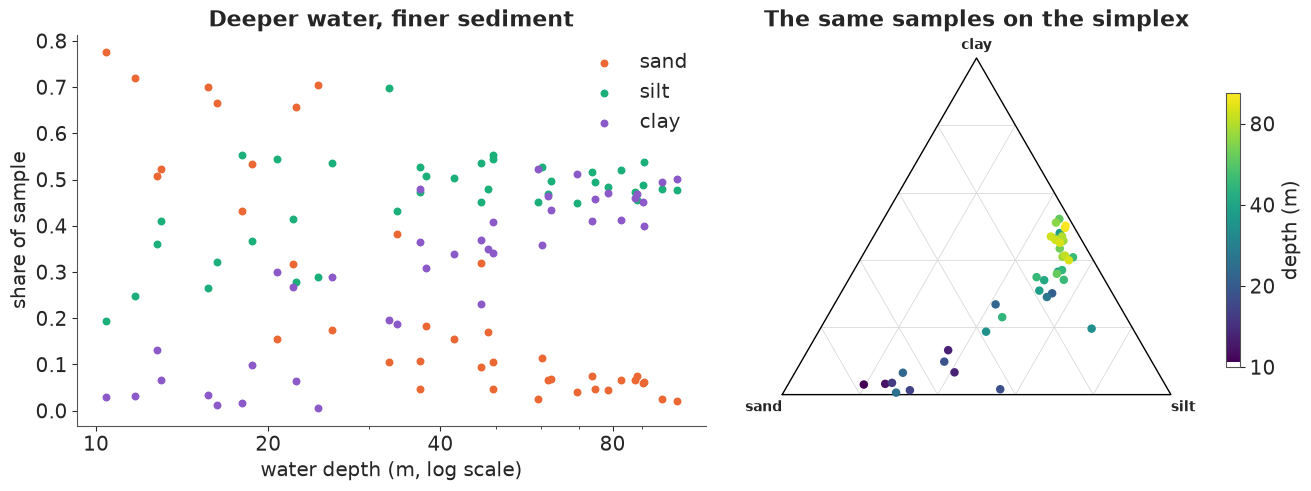

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), width_ratios=[1.3, 1])
cols3 = [ORANGE, AQUA, PURPLE]
for k, (p, c) in enumerate(zip(PART3, cols3)):
    axes[0].scatter(depth, X3[:, k], color=c, s=22, label=p)
axes[0].set(xscale="log", xlabel="water depth (m, log scale)", ylabel="share of sample",
            title="Deeper water, finer sediment")
axes[0].set_xticks([10, 20, 40, 80], ["10", "20", "40", "80"])
axes[0].legend()
tern_axes(axes[1], PART3)
sc = axes[1].scatter(*tern_xy(X3), c=np.log(depth), cmap="viridis", s=26, zorder=3)
cb = fig.colorbar(sc, ax=axes[1], shrink=0.7, label="depth (m)")
cb.set_ticks(np.log([10, 20, 40, 80]), labels=["10", "20", "40", "80"])
axes[1].set_title("The same samples on the simplex");

Shallow samples are mostly sand; with depth the sand gives way to silt and then clay. On the
ternary plot (sand bottom-left, silt bottom-right, clay top) the samples trace a curved path
from near the sand corner up towards the silt-clay edge; the deep samples (yellow) are
bunched close to that edge, at a few percent sand and silt : clay roughly 1 : 1. Shallow
samples are much more scattered than deep ones.

## 1.2 · Ordinary regression on the shares

The obvious first model is a separate linear regression of each share on log depth. Because
the three responses sum to one and share the same design, the three fitted lines also sum to
one exactly - so far so good. But nothing keeps them between 0 and 1.

OLS prediction at   5 m: sand +0.879, silt +0.281, clay -0.161  (sum 1.000)
OLS prediction at 150 m: sand -0.172, silt +0.571, clay +0.601  (sum 1.000)


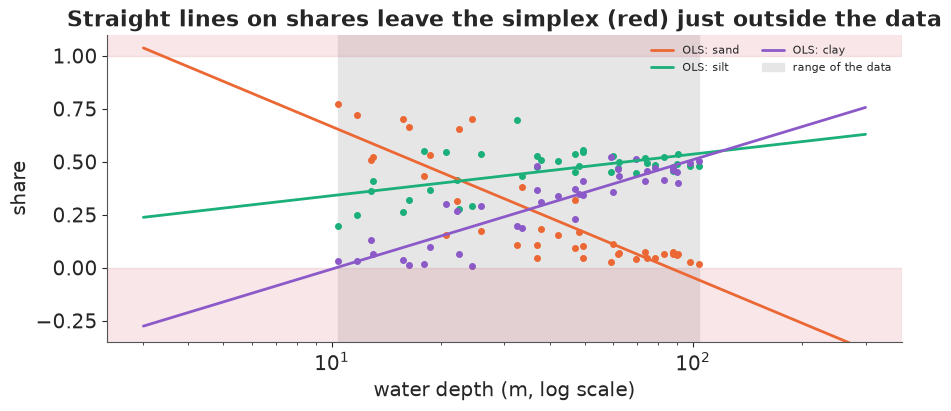

In [5]:
D1 = np.c_[np.ones(39), xd]
B_ols = np.linalg.lstsq(D1, X3, rcond=None)[0]
grid_depth = np.geomspace(3, 300, 200)
fit_ols = np.c_[np.ones(200), np.log2(grid_depth / 40)] @ B_ols
for d in [5, 150]:
    pred = np.array([1, np.log2(d / 40)]) @ B_ols
    print(f"OLS prediction at {d:>3} m: " + ", ".join(f"{p} {v:+.3f}" for p, v in zip(PART3, pred))
          + f"  (sum {pred.sum():.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
for k, (p, c) in enumerate(zip(PART3, cols3)):
    ax.scatter(depth, X3[:, k], color=c, s=16)
    ax.plot(grid_depth, fit_ols[:, k], color=c, lw=2, label=f"OLS: {p}")
ax.axhspan(-0.5, 0, color=RED, alpha=0.12)
ax.axhspan(1, 1.5, color=RED, alpha=0.12)
ax.axvspan(depth.min(), depth.max(), color="0.9", zorder=0, label="range of the data")
ax.set(xscale="log", ylim=(-0.35, 1.1), xlabel="water depth (m, log scale)", ylabel="share",
       title="Straight lines on shares leave the simplex (red) just outside the data")
ax.legend(fontsize=8, ncol=2);

At 5 m ordinary least squares predicts a **negative clay share**, at 150 m a **negative sand
share**. These are not far-fetched extrapolations: the data span 10-104 m. Even inside the data
range the straight lines are wrong in shape (sand flattens out near zero; it cannot keep
falling linearly), and the residual scatter is plainly smaller near 0 than in the middle.

## 1.3 · Closure makes correlations lie

A subtler problem. Take silt and clay. Across the 39 samples their shares are *positively*
correlated. Now remove sand and renormalise to the silt-clay **subcomposition** - the same
physical material, just ignoring the coarse fraction. With two parts left, one is 1 minus the
other, so the correlation becomes exactly $-1$.

In [6]:
sub = closure(X3[:, 1:])
print(f"corr(silt, clay) in the full composition:   {np.corrcoef(X3[:, 1], X3[:, 2])[0, 1]:+.2f}")
print(f"corr(silt, clay) in the silt-clay subcomposition: {np.corrcoef(sub[:, 0], sub[:, 1])[0, 1]:+.2f}")
lr_full, lr_sub = np.log(X3[:, 1] / X3[:, 2]), np.log(sub[:, 0] / sub[:, 1])
print(f"log(silt/clay) is identical in both: max difference {np.abs(lr_full - lr_sub).max():.1e}")
print("correlation matrix of the raw shares:\n",
      pd.DataFrame(np.corrcoef(X3.T), PART3, PART3).round(2))

corr(silt, clay) in the full composition:   +0.59
corr(silt, clay) in the silt-clay subcomposition: -1.00
log(silt/clay) is identical in both: max difference 4.4e-16
correlation matrix of the raw shares:
       sand  silt  clay
sand  1.00 -0.83 -0.94
silt -0.83  1.00  0.59
clay -0.94  0.59  1.00


The sign of the correlation depends on which other parts you happened to measure, so raw-share
correlations do not describe the silt-clay relationship (Pearson warned about this "spurious
correlation" of ratios in 1897; Aitchison called the requirement **subcompositional
coherence**). The ratio $\text{silt}/\text{clay}$, by contrast, is the same whether or not sand
is in the picture. That is the starting point of the log-ratio approach.

---
# 2 · Log-ratio geometry: ALR, CLR, ILR and the reference part

For a composition $x = (x_1, \dots, x_D)$ the three standard log-ratio transforms are:

* **ALR** (additive log-ratio) with a reference part $D$: $\;\text{alr}(x)_j = \log(x_j / x_D)$,
  $j = 1, \dots, D-1$. Simple and interpretable ("clay relative to sand"), but it singles out
  one part.
* **CLR** (centred log-ratio): $\;\text{clr}(x)_j = \log\big(x_j / g(x)\big)$ with $g$ the
  geometric mean of all parts. Symmetric in the parts, but its $D$ coordinates sum to zero, so
  its covariance matrix is singular - good for *reporting*, awkward as a likelihood.
* **ILR** (isometric log-ratio): $D - 1$ orthonormal coordinates, often chosen as
  **balances** between groups of parts. For our three parts:
  $z_1 = \sqrt{2/3}\,\log\big(\text{sand}/\sqrt{\text{silt}\cdot\text{clay}}\big)$ (coarse vs
  fine) and $z_2 = \sqrt{1/2}\,\log(\text{silt}/\text{clay})$ (within the fine fraction).

All three are linear maps of $\log x$, so each is a linear transform of any other. The
inverse of ALR is the **softmax** of $(0, \text{alr}_1, \dots, \text{alr}_{D-1})$ - the same
link a multinomial logit uses - so a softmax of a linear predictor always gives a valid
composition.

ILR basis orthonormal: True
reference = sand: slopes per doubling log(silt/sand) +1.14, log(clay/sand) +1.90
reference = clay: slopes per doubling log(sand/clay) -1.90, log(silt/clay) -0.76
fitted compositions differ by at most 3.3e-16


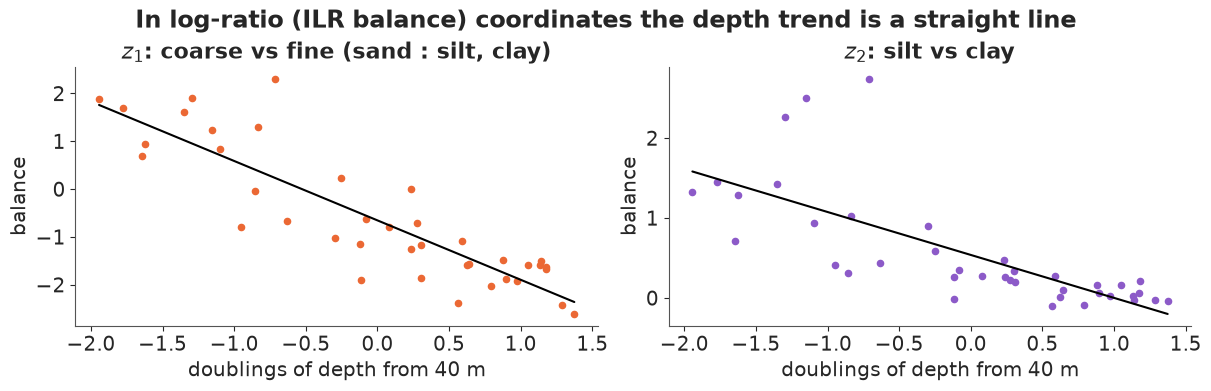

In [7]:
def alr(x, ref=0):
    x = np.asarray(x, float)
    return np.log(np.delete(x, ref, axis=-1) / x[..., [ref]])


def clr(x):
    lx = np.log(x)
    return lx - lx.mean(axis=-1, keepdims=True)


V_ilr = np.array([[np.sqrt(2 / 3), -np.sqrt(1 / 6), -np.sqrt(1 / 6)],   # sand vs (silt, clay)
                  [0.0, np.sqrt(1 / 2), -np.sqrt(1 / 2)]])                 # silt vs clay
ilr = clr(X3) @ V_ilr.T
print("ILR basis orthonormal:", np.allclose(V_ilr @ V_ilr.T, np.eye(2)))

# A multivariate regression on the ALR with two different reference parts
fits = {}
for ref in [0, 2]:
    A = alr(X3, ref)
    B = np.linalg.lstsq(D1, A, rcond=None)[0]
    eta = np.insert(D1 @ B, ref, 0.0, axis=1)
    fits[ref] = special.softmax(eta, axis=1)
    print(f"reference = {PART3[ref]:>4}: slopes per doubling "
          + ", ".join(f"log({p}/{PART3[ref]}) {b:+.2f}"
                      for p, b in zip(np.delete(PART3, ref), B[1])))
print(f"fitted compositions differ by at most {np.abs(fits[0] - fits[2]).max():.1e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for k, (ax, lab) in enumerate(zip(axes, ["$z_1$: coarse vs fine (sand : silt, clay)",
                                         "$z_2$: silt vs clay"])):
    ax.scatter(xd, ilr[:, k], color=[ORANGE, PURPLE][k], s=20)
    b = np.polyfit(xd, ilr[:, k], 1)
    ax.plot(np.sort(xd), np.polyval(b, np.sort(xd)), color="k", lw=1.5)
    ax.set(xlabel="doublings of depth from 40 m", ylabel="balance", title=lab)
fig.suptitle("In log-ratio (ILR balance) coordinates the depth trend is a straight line");

Two useful facts:

* **The reference part does not matter for the fit.** The ALR slopes change meaning with the
  reference ("silt relative to sand" vs "silt relative to clay"), but a least-squares fit - or
  any model with a full covariance matrix, as below - gives *identical* fitted compositions.
  In a Bayesian model the reference choice can still matter a little through the prior (an
  LKJ prior on one ALR basis is not exactly the same prior on another) and matters a lot for
  *interpretation*. A common default is the part that is **never zero** and **never tiny**.
* **In log-ratio coordinates the trend is close to linear.** The coarse-vs-fine balance
  falls steadily with depth and the silt-clay balance tilts towards clay. Note the scatter
  around the lines: it is clearly *larger in shallow water* than in deep water. We will come
  back to this.

---
# 3 · Dirichlet regression, and a predictive check it cannot pass

## 3.1 · The model

The natural distribution on the simplex is the **Dirichlet**. In the **mean-precision**
parameterisation $y_i \sim \text{Dirichlet}(\phi\,\mu_i)$, $\mu_i$ is the expected composition
and $\phi$ a precision: $\text{Var}(y_{ij}) = \mu_{ij}(1 - \mu_{ij})/(\phi + 1)$. The mean
gets a softmax link with sand as the reference:

$$\mu_i = \operatorname{softmax}\big(0,\; a_1 + b_1 x_i,\; a_2 + b_2 x_i\big), \qquad
  x_i = \log_2(\text{depth}_i / 40).$$

so $b_1$ is the change in $\log(\text{silt}/\text{sand})$ per doubling of depth. Priors: $a
\sim N(0, 1.5)$ (a sample at 40 m could be anything from 5% to 95% of a part), $b \sim N(0,
1)$ per doubling, and $\phi \sim \text{Gamma}(2, 0.1)$ (mean 20: "as variable as a handful of
grains" up to fairly tight). The prior predictive check draws whole datasets and looks at them
on the triangle at the shallowest and deepest sample.

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(


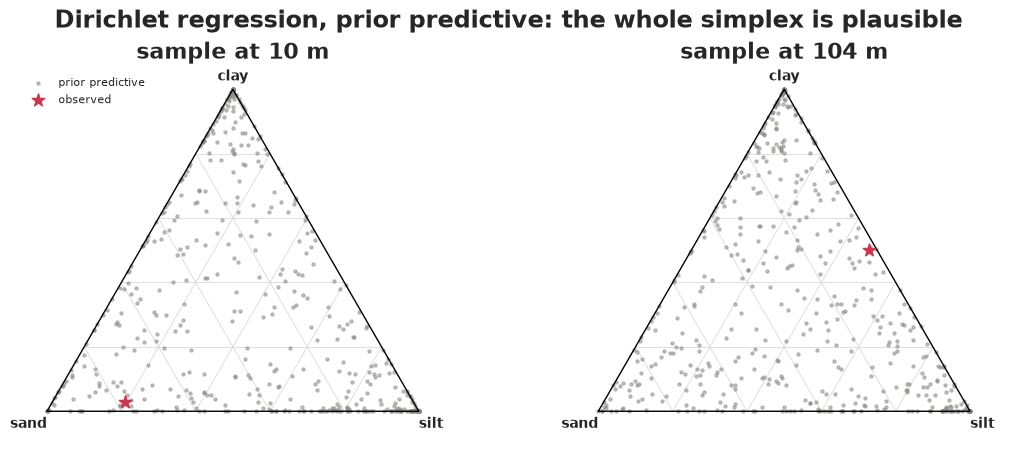

In [8]:
coords3 = {"sample": np.arange(39), "part": PART3, "ratio": ["silt/sand", "clay/sand"]}
with pm.Model(coords=coords3) as m_dir:
    a = pm.Normal("a", 0, 1.5, dims="ratio")
    b = pm.Normal("b", 0, 1, dims="ratio")
    phi = pm.Gamma("phi", 2, 0.1)
    eta = pt.concatenate([pt.zeros((39, 1)), a + b * xd[:, None]], axis=1)
    mu = pm.Deterministic("mu", pm.math.softmax(eta, axis=1), dims=("sample", "part"))
    pm.Dirichlet("y", a=phi * mu, observed=X3, dims=("sample", "part"))
    prior_dir = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)

yp = draws(prior_dir, "y", "prior_predictive")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, i in zip(axes, [0, 38]):
    tern_axes(ax, PART3)
    ax.scatter(*tern_xy(yp[:, i]), s=5, color=GREY, alpha=0.5, label="prior predictive")
    ax.scatter(*tern_xy(X3[i]), s=90, color=RED, marker="*", zorder=4, label="observed")
    ax.set_title(f"sample at {depth[i]:.0f} m")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Dirichlet regression, prior predictive: the whole simplex is plausible");

The prior predictive covers the whole triangle, including near-pure samples, and does not
prefer any corner - weakly informative, as intended. Now the fit.

In [9]:
t0 = time.time()
with m_dir:
    idata_dir = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata_dir, progressbar=False)
    pm.sample_posterior_predictive(idata_dir, extend_inferencedata=True,
                                   random_seed=RANDOM_SEED, progressbar=False)
fit_report(idata_dir, ["a", "b", "phi"], t0)
az.summary(idata_dir, var_names=["a", "b", "phi"], round_to=3)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(


2 s, max r_hat 1.001, min bulk ESS 1901, divergences 0, tuning steps 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[silt/sand],1.014,0.111,0.836,1.193,1901.243,2356.809,1.001,0.003,0.002
a[clay/sand],0.375,0.117,0.184,0.562,2244.305,2122.065,1.001,0.002,0.002
b[silt/sand],1.010,0.108,0.837,1.184,2061.926,2461.573,1.001,0.002,0.002
b[clay/sand],1.606,0.133,1.394,1.821,2050.277,2362.574,1.001,0.003,0.002
phi,17.441,2.816,13.177,21.991,3506.085,3125.991,1.001,0.047,0.041


Clean sampling. Per doubling of depth, $\log(\text{silt}/\text{sand})$ rises by about 1.0 and
$\log(\text{clay}/\text{sand})$ by about 1.6: the silt-to-sand ratio multiplies by
$e^{1.0} \approx 2.7$ and the clay-to-sand ratio by $e^{1.6} \approx 5$ each time the depth
doubles. The precision $\phi \approx 18$ says a sample scatters around its expected
composition about as much as a composition built from 18 grains would.

## 3.2 · A check aimed at how the parts vary

Shares-vs-depth plots with predictive bands would look acceptable. The questions a Dirichlet
should be asked are about its **variance structure**, because the family fixes it:

* every pair of parts has a *negative* covariance, $\text{Cov}(y_j, y_k) = -\mu_j
  \mu_k/(\phi + 1)$, whatever the parameters (we will test this on the votes, where it
  matters most);
* on the log scale, $\text{Var}(\log y_j) = \psi_1(\phi\mu_j) - \psi_1(\phi)$ ($\psi_1$ the
  trigamma function), which *grows* as a part's expected share $\mu_j$ shrinks. The
  Dirichlet says **small parts are erratic on the log scale** - a part expected at 3% should
  sometimes turn up at 0.1%.

The ILR plot in section 2 suggested the opposite: the scatter of the balances is *large* in
shallow water and *small* in deep water, where sand is a small part. Two statistics, computed
on the observed data and on every replicated dataset: the residual standard deviation of the
coarse-vs-fine balance $z_1$ (after the same straight-line fit on log depth) among the **12
shallow samples** (< 25 m) and among the **15 deep samples** (> 50 m).

In [10]:
shallow, deep = depth < 25, depth > 50
print(f"{shallow.sum()} shallow samples (< 25 m), {deep.sum()} deep samples (> 50 m)")


def lake_stats(Y):
    """Residual sd of balance z1 among shallow and among deep samples."""
    z1 = clr(closure(np.clip(Y, 1e-300, None))) @ V_ilr[0]
    r = z1 - D1 @ np.linalg.lstsq(D1, z1, rcond=None)[0]
    return r[shallow].std(), r[deep].std()


def ppc_stats(Yrep, n=1000):
    return np.array([lake_stats(y) for y in Yrep[:: max(1, len(Yrep) // n)]])


def report(T, name):
    for k, lab in enumerate(["T_shallow", "T_deep"]):
        print(f"{name:<24} {lab:<9} observed {T_obs[k]:.2f}; replicates {q(T[:, k])}; "
              f"P(T_rep >= T_obs) = {np.mean(T[:, k] >= T_obs[k]):.3f}")


T_obs = np.array(lake_stats(X3))
T_dir = ppc_stats(draws(idata_dir, "y", "posterior_predictive"))
report(T_dir, "Dirichlet")
print(f"smallest sand share among deep samples: observed {X3[deep, 0].min():.3f}; Dirichlet "
      f"replicates {q(draws(idata_dir, 'y', 'posterior_predictive')[:, deep, 0].min(axis=1), (0.05, 0.5, 0.95))}")

12 shallow samples (< 25 m), 15 deep samples (> 50 m)
Dirichlet                T_shallow observed 0.85; replicates [0.31 0.48 0.74]; P(T_rep >= T_obs) = 0.018
Dirichlet                T_deep    observed 0.42; replicates [0.56 0.92 1.58]; P(T_rep >= T_obs) = 0.993
smallest sand share among deep samples: observed 0.020; Dirichlet replicates [0.   0.   0.02]


The Dirichlet fails in both directions at once. In shallow water, where the parts are all
of moderate size, it predicts too *little* scatter of the coarse-vs-fine balance; in deep water,
where sand is only a few percent, it predicts about twice the observed scatter, because it
expects the small sand share to be erratic on the log scale (the smallest sand share among the
15 deep samples of a replicate is typically below half a percent; the real minimum is 2%). This is not bad
luck or a bad prior: with one precision $\phi$ the Dirichlet ties the log-scale scatter of
every part to its mean.

---
# 4 · The logistic-normal model

## 4.1 · MvNormal on log-ratios with an LKJ covariance

The **logistic-normal** (Aitchison & Shen 1980) models the ALR coordinates as multivariate
normal:

$$\text{alr}(y_i) \sim \text{MvNormal}\big(a + b\,x_i,\; \Sigma\big), \qquad
  \Sigma = \operatorname{diag}(s)\,\Omega\,\operatorname{diag}(s), \quad
  \Omega \sim \text{LKJ}(2),\; s_j \sim \text{Exponential}(1).$$

The mean structure is the same as the Dirichlet regression's (same link, same priors on $a$
and $b$), but the log-ratio scatter is now a free covariance matrix ($D(D-1)/2 = 3$
parameters) that does not depend on the mean, and correlations of either sign are allowed.

In [11]:
alr3 = alr(X3, ref=0)                     # log(silt/sand), log(clay/sand)
with pm.Model(coords=coords3) as m_ln:
    a = pm.Normal("a", 0, 1.5, dims="ratio")
    b = pm.Normal("b", 0, 1, dims="ratio")
    chol, corr, sds = pm.LKJCholeskyCov("chol", n=2, eta=2.0, sd_dist=pm.Exponential.dist(1.0),
                                        compute_corr=True)
    pm.Deterministic("rho", corr[0, 1])
    pm.Deterministic("s", sds, dims="ratio")
    pm.MvNormal("alr", mu=a + b * xd[:, None], chol=chol, observed=alr3, dims=("sample", "ratio"))

t0 = time.time()
with m_ln:
    idata_ln = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata_ln, progressbar=False)
    pm.sample_posterior_predictive(idata_ln, extend_inferencedata=True,
                                   random_seed=RANDOM_SEED, progressbar=False)
fit_report(idata_ln, ["a", "b", "rho", "s"], t0)


def alr_to_comp(alr_draws):
    z = np.zeros(alr_draws.shape[:-1] + (1,))
    return special.softmax(np.concatenate([z, alr_draws], axis=-1), axis=-1)


T_ln = ppc_stats(alr_to_comp(draws(idata_ln, "alr", "posterior_predictive")))
report(T_ln, "logistic-normal")
az.summary(idata_ln, var_names=["a", "b", "rho", "s"], round_to=3)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(


5 s, max r_hat 1.002, min bulk ESS 1856, divergences 0, tuning steps 400
logistic-normal          T_shallow observed 0.85; replicates [0.39 0.62 0.91]; P(T_rep >= T_obs) = 0.075
logistic-normal          T_deep    observed 0.42; replicates [0.42 0.63 0.91]; P(T_rep >= T_obs) = 0.950


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[silt/sand],1.170,0.105,1.003,1.336,1876.781,1893.376,1.001,0.002,0.002
a[clay/sand],0.400,0.189,0.099,0.700,1855.897,1839.328,1.001,0.004,0.003
b[silt/sand],1.102,0.105,0.931,1.269,2290.966,2235.873,1.002,0.002,0.002
b[clay/sand],1.822,0.190,1.516,2.115,2227.779,2089.630,1.002,0.004,0.004
rho,0.792,0.060,0.685,0.876,2901.334,2604.299,1.000,0.001,0.001
s[silt/sand],0.626,0.072,0.521,0.751,2704.916,2250.590,1.000,0.001,0.001
s[clay/sand],1.124,0.129,0.936,1.347,2378.606,2391.065,1.001,0.003,0.002


Better, but a constant $\Sigma$ predicts the *same* log-ratio scatter at every depth, so it
splits the difference: the observed deep-water scatter is now in the lower tail of the
replicates rather than far outside them, and the shallow-water scatter in the upper tail.

## 4.2 · Letting the scatter change with depth

The fix is to model what the plot showed: a log-ratio scale that changes with depth,

$$\text{alr}(y_i) \sim \text{MvNormal}\big(a + b\,x_i,\; D_i\,\Sigma\,D_i\big), \qquad
  D_i = \operatorname{diag}\big(e^{g_1 x_i}, e^{g_2 x_i}\big),\; g_j \sim N(0, 0.5),$$

so $e^{g_j}$ is the factor by which the scatter of log-ratio $j$ changes per doubling of depth.
In PyMC this is a batched Cholesky factor: one $2\times 2$ factor per sample.

In [12]:
with pm.Model(coords=coords3) as m_lnh:
    a = pm.Normal("a", 0, 1.5, dims="ratio")
    b = pm.Normal("b", 0, 1, dims="ratio")
    g = pm.Normal("g", 0, 0.5, dims="ratio")
    chol, corr, sds = pm.LKJCholeskyCov("chol", n=2, eta=2.0, sd_dist=pm.Exponential.dist(1.0),
                                        compute_corr=True)
    pm.Deterministic("rho", corr[0, 1])
    pm.Deterministic("s", sds, dims="ratio")       # scale at 40 m
    scale = pt.exp(g[None, :] * xd[:, None])        # (sample, ratio)
    pm.MvNormal("alr", mu=a + b * xd[:, None], chol=scale[:, :, None] * chol[None],
                observed=alr3, dims=("sample", "ratio"))

t0 = time.time()
with m_lnh:
    idata_lnh = pm.sample(random_seed=RANDOM_SEED, target_accept=0.9, progressbar=False)
    pm.compute_log_likelihood(idata_lnh, progressbar=False)
    pm.sample_posterior_predictive(idata_lnh, extend_inferencedata=True,
                                   random_seed=RANDOM_SEED, progressbar=False)
fit_report(idata_lnh, ["a", "b", "g", "rho", "s"], t0)
T_lnh = ppc_stats(alr_to_comp(draws(idata_lnh, "alr", "posterior_predictive")))
report(T_lnh, "LN, depth-varying scale")
g_d = draws(idata_lnh, "g")
print("scatter factor per doubling of depth, exp(g):",
      {r: q(np.exp(g_d[:, k])) for k, r in enumerate(coords3["ratio"])})
az.summary(idata_lnh, var_names=["a", "b", "g", "rho", "s"], round_to=3)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(


2 s, max r_hat 1.005, min bulk ESS 669, divergences 0, tuning steps 400
LN, depth-varying scale  T_shallow observed 0.85; replicates [0.75 1.26 2.06]; P(T_rep >= T_obs) = 0.887
LN, depth-varying scale  T_deep    observed 0.42; replicates [0.23 0.36 0.54]; P(T_rep >= T_obs) = 0.274
scatter factor per doubling of depth, exp(g): {'silt/sand': array([0.57, 0.69, 0.84]), 'clay/sand': array([0.42, 0.51, 0.62])}


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_base/base.py:137: UserWarning: Found dimension named 'sample' alongside 'chain'/'draw' ones, check dimensions are correctly named.
  warnings.warn(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[silt/sand],1.264,0.111,1.087,1.448,891.377,1332.778,1.003,0.004,0.002
a[clay/sand],0.667,0.197,0.360,0.986,752.168,958.811,1.003,0.007,0.004
b[silt/sand],0.970,0.112,0.786,1.145,860.668,1232.079,1.004,0.004,0.002
b[clay/sand],1.473,0.193,1.166,1.783,668.754,1007.393,1.005,0.007,0.005
g[silt/sand],-0.373,0.121,-0.563,-0.176,1708.465,2265.743,1.001,0.003,0.002
g[clay/sand],-0.680,0.117,-0.862,-0.484,1931.050,2326.529,1.000,0.003,0.002
rho,0.892,0.039,0.823,0.942,1907.497,2624.576,1.001,0.001,0.001
s[silt/sand],0.625,0.074,0.520,0.753,2016.019,2414.579,1.000,0.002,0.001
s[clay/sand],0.981,0.113,0.819,1.172,1940.708,2398.993,1.000,0.003,0.002


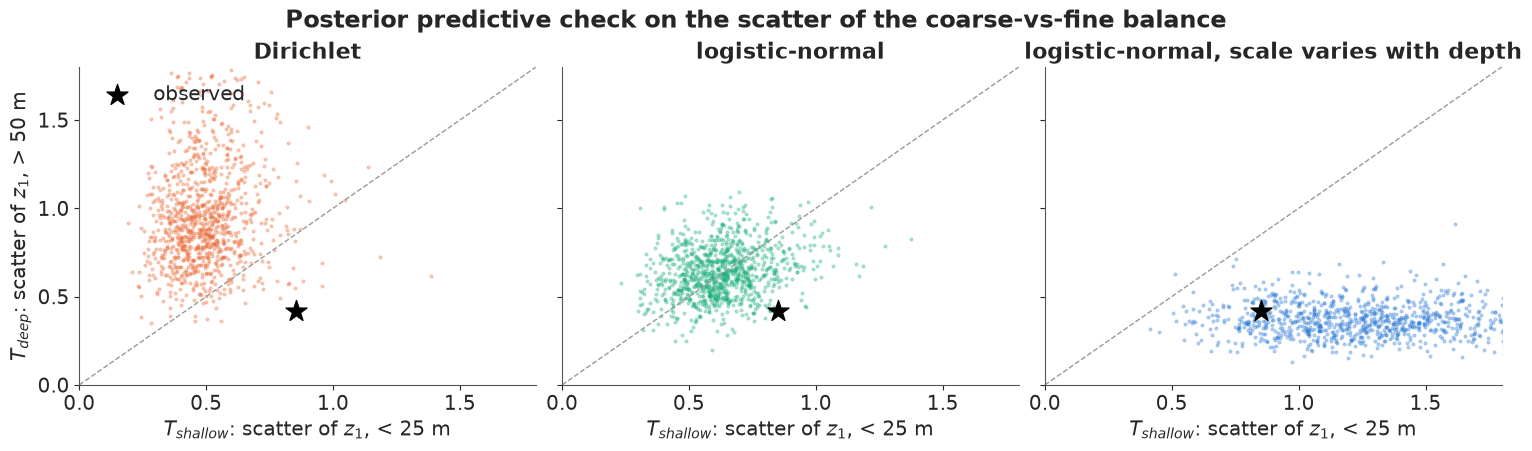

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, sharey=True)
for ax, (T, nm, c) in zip(axes, [(T_dir, "Dirichlet", ORANGE), (T_ln, "logistic-normal", AQUA),
                                (T_lnh, "logistic-normal, scale varies with depth", BLUE)]):
    ax.scatter(T[:, 0], T[:, 1], s=4, alpha=0.3, color=c)
    ax.scatter(*T_obs, marker="*", s=250, color="k", zorder=4, label="observed")
    ax.plot([0, 3], [0, 3], color="0.6", lw=1, ls="--")
    ax.set(title=nm, xlabel="$T_{shallow}$: scatter of $z_1$, < 25 m", xlim=(0, 1.8), ylim=(0, 1.8))
axes[0].set_ylabel("$T_{deep}$: scatter of $z_1$, > 50 m")
axes[0].legend(loc="upper left")
fig.suptitle("Posterior predictive check on the scatter of the coarse-vs-fine balance");

Each dot is one replicated dataset; the star is the real one. The Dirichlet's cloud lies above
the diagonal (more scatter in deep water) and the real data sit well below and to the right of
it. The constant-covariance logistic-normal straddles the diagonal and the star sits on the
edge of its cloud. With a depth-varying scale the star is inside the cloud, though towards
its low-$T_{shallow}$ edge: an exponential trend in the scale, fitted mostly to the many
samples at 20-100 m, somewhat overshoots in the shallowest water. The estimated scatter
factors are below one: the log-ratio scatter shrinks by roughly a third (silt/sand) to a half
(clay/sand) per doubling of depth, so deep-water sediment is far more uniform than
shallow-water sediment. (This model mixes a little less well - bulk ESS of several hundred
rather than about 2,000, r_hat up to about 1.01 across runs - because the depth trends of the
mean and the scale trade off; it is adequate for these summaries.)

## 4.3 · Comparing Dirichlet and logistic-normal models by LOO: mind the scale

The Dirichlet's log-likelihood is a density of the **shares**; the logistic-normal's is a
density of the **log-ratios**. Comparing those two numbers directly is comparing apples with
log-apples. Changing variables from $x$ (on the simplex) to $\text{alr}(x)$ has Jacobian
$\prod_{j=1}^{D} x_j^{-1}$, so the logistic-normal density of the shares is

$$\log p(x) = \log p_{\text{MvN}}\big(\text{alr}(x)\big) - \sum_{j=1}^D \log x_j .$$

The correction is a constant per observation (it does not depend on parameters), so it does
not change the fit - but it moves the elpd by $-\sum_i\sum_j \log x_{ij}$, a large positive
number here because shares are below one.

In [14]:
jac = -np.log(X3).sum(axis=1)


def on_share_scale(idata):
    ll = idata["log_likelihood"]["alr"]
    ll = ll + xr.DataArray(jac, dims=ll.dims[-1:])
    return xr.DataTree.from_dict({"posterior": idata.posterior.to_dataset(),
                                  "log_likelihood": xr.Dataset({"y": ll})})


loo_dir = az.loo(idata_dir, var_name="y", pointwise=True)
loo_ln_wrong = az.loo(idata_ln, var_name="alr", pointwise=True)
loo_ln = az.loo(on_share_scale(idata_ln), var_name="y", pointwise=True)
loo_lnh = az.loo(on_share_scale(idata_lnh), var_name="y", pointwise=True)
print(f"total Jacobian term: {jac.sum():+.1f} nats")
print(f"elpd Dirichlet (shares)                  {loo_dir.elpd:7.1f} (se {loo_dir.se:.1f})")
print(f"elpd logistic-normal (log-ratio scale!)  {loo_ln_wrong.elpd:7.1f} (se {loo_ln_wrong.se:.1f})"
      "  <- not comparable")
for nm, lo in [("Dirichlet", loo_dir), ("logistic-normal", loo_ln), ("LN, varying scale", loo_lnh)]:
    print(f"  {nm:<18} Pareto k > 0.7 for {int((lo.pareto_k > 0.7).sum())} of 39 samples")
az.compare({"Dirichlet": loo_dir, "logistic-normal": loo_ln, "LN, varying scale": loo_lnh},
           round_to=1)

total Jacobian term: +170.5 nats
elpd Dirichlet (shares)                     83.6 (se 9.9)
elpd logistic-normal (log-ratio scale!)    -81.2 (se 10.7)  <- not comparable
  Dirichlet          Pareto k > 0.7 for 0 of 39 samples
  logistic-normal    Pareto k > 0.7 for 2 of 39 samples
  LN, varying scale  Pareto k > 0.7 for 1 of 39 samples


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
"LN, varying scale",0,0.0,0.0,NaN,,1 k̂ > 0.70,9.9,105.0,9.5,0.9
logistic-normal,1,-15.8,5.0,1.0,N < 100,2 k̂ > 0.70,8.6,89.3,9.0,0.0
Dirichlet,2,-21.4,7.3,1.0,N < 100,,6.6,83.6,9.9,0.1


On the log-ratio scale the logistic-normal would appear to lose to the Dirichlet by over 160
nats; on the common share scale the ordering is the same as the predictive checks: the
depth-varying logistic-normal first, about 16 nats ahead of the constant one and 21 ahead of
the Dirichlet, each about three standard errors of the difference. One or two samples have
Pareto $k > 0.7$, so exact refits for them would be needed before quoting the numbers
precisely. **Whenever two models describe the
data on different scales, put their densities on one scale before comparing.**

## 4.4 · The answer: predicted compositions and which parts change with depth

Two questions a sedimentologist would ask: *what composition should I expect at a given depth*
(including depths outside the sampled range), and *which grain sizes gain and lose with
depth*? For the second, ALR slopes depend on the reference part. The reference-free answer is
the **CLR effect**: the change in $\log(x_j/g(x))$ per doubling, i.e. each part relative to the
geometric mean of all parts, $b^{\text{clr}} = (0, b_1, b_2) - \text{mean}(0, b_1, b_2)$.

CLR effect per doubling of depth (5%, 50%, 95%):
  sand  [-0.97 -0.82 -0.65]  -> x0.44 relative to the geometric mean
  silt  [0.09 0.16 0.22]  -> x1.17 relative to the geometric mean
  clay  [0.49 0.66 0.82]  -> x1.93 relative to the geometric mean


,depth (m),"sand: new sample, median (90%)","silt: new sample, median (90%)","clay: new sample, median (90%)",P(clay > silt)
0,15,0.45 (0.04-0.86),0.34 (0.09-0.58),0.11 (0.00-0.78),0.22
1,40,0.16 (0.05-0.37),0.52 (0.38-0.64),0.29 (0.13-0.52),0.12
2,100,0.04 (0.02-0.07),0.47 (0.39-0.54),0.49 (0.41-0.58),0.63
3,150,0.02 (0.01-0.03),0.41 (0.32-0.48),0.58 (0.50-0.66),0.97


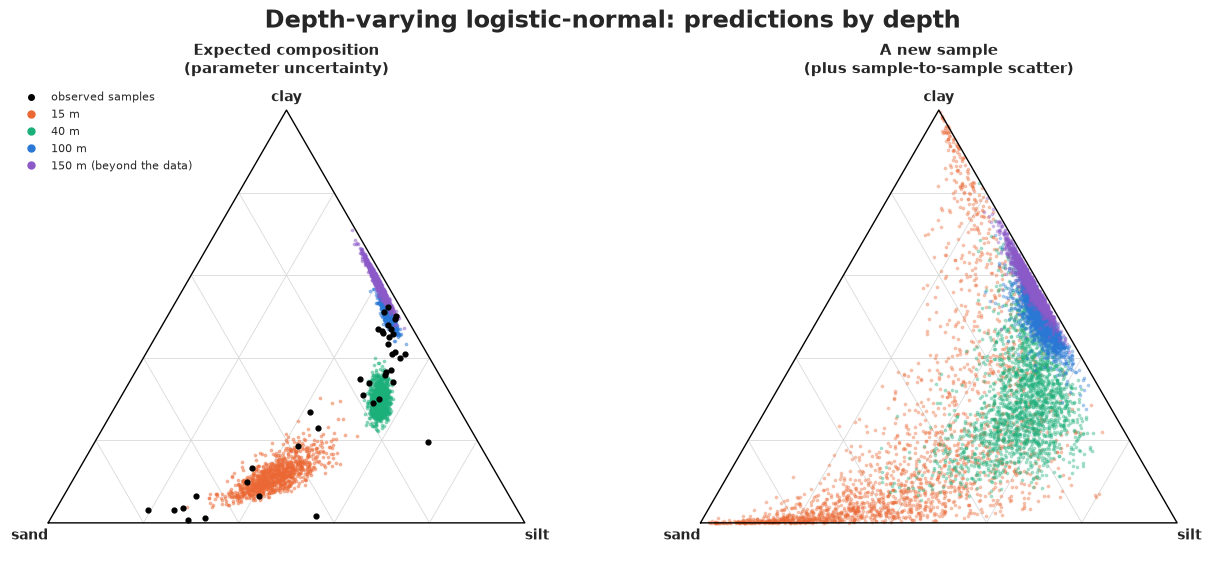

In [15]:
post_a, post_b = draws(idata_lnh, "a"), draws(idata_lnh, "b")
chol_draws = draws(idata_lnh, "chol")          # packed lower triangle (l00, l10, l11)
b_full = np.c_[np.zeros(len(post_b)), post_b]
b_clr = b_full - b_full.mean(axis=1, keepdims=True)
print("CLR effect per doubling of depth (5%, 50%, 95%):")
for k, p in enumerate(PART3):
    print(f"  {p:<5} {q(b_clr[:, k])}  -> x{np.exp(np.median(b_clr[:, k])):.2f} relative to the "
          f"geometric mean")

L = np.zeros((len(chol_draws), 2, 2))
L[:, 0, 0], L[:, 1, 0], L[:, 1, 1] = chol_draws[:, 0], chol_draws[:, 1], chol_draws[:, 2]
new_depths = [15, 40, 100, 150]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
tern_axes(axes[0], PART3)
tern_axes(axes[1], PART3)
axes[0].scatter(*tern_xy(X3), s=12, color="k", zorder=3)
handles = [Line2D([], [], marker="o", ls="", color="k", ms=4, label="observed samples")]
rows = []
for d, c in zip(new_depths, [ORANGE, AQUA, BLUE, PURPLE]):
    x_new = np.log2(d / 40)
    eta_mean = post_a + post_b * x_new
    mean_comp = alr_to_comp(eta_mean)
    eps = np.einsum("sij,sj->si", L, rng.standard_normal((len(L), 2))) * np.exp(g_d * x_new)
    new_sample = alr_to_comp(eta_mean + eps)
    tag = f"{d} m" + (" (beyond the data)" if d > depth.max() else "")
    axes[0].scatter(*tern_xy(mean_comp[::4]), s=3, color=c, alpha=0.4)
    axes[1].scatter(*tern_xy(new_sample[::2]), s=3, color=c, alpha=0.3)
    handles.append(Line2D([], [], marker="o", ls="", color=c, ms=5, label=tag))
    rows.append({"depth (m)": d,
                 **{f"{p}: new sample, median (90%)":
                    f"{np.median(new_sample[:, k]):.2f} ({np.quantile(new_sample[:, k], 0.05):.2f}"
                    f"-{np.quantile(new_sample[:, k], 0.95):.2f})" for k, p in enumerate(PART3)},
                 "P(clay > silt)": np.mean(new_sample[:, 2] > new_sample[:, 1])})
axes[0].legend(handles=handles, loc="upper left", fontsize=8)
axes[0].set_title("Expected composition\n(parameter uncertainty)", fontsize=11)
axes[1].set_title("A new sample\n(plus sample-to-sample scatter)", fontsize=11)
fig.suptitle("Depth-varying logistic-normal: predictions by depth");
pd.DataFrame(rows).round(2)

Reading the CLR effects: with each doubling of depth, clay gains strongly and sand loses
strongly relative to the geometric mean of the three parts, while silt changes little; whatever
reference we had chosen for the ALR, this statement would be the same. On the triangle the
*expected* composition moves along a curved path (a straight line in log-ratio space is a
curve on the simplex) from the sand corner towards the silt-clay edge, with small uncertainty
inside the data range. A *new* sample is far more uncertain, above all in shallow water: at
15 m its 90% interval for sand runs from a few percent to over 80%, and even a clay-rich sample
is not excluded - partly the overshoot of the exponential scale noted in 4.2, so treat the
shallow end of this prediction as generous. In deep water new samples are tight (sand 2-7% at
100 m), much tighter than the constant-covariance model would say.
At 150 m, beyond the deepest sample, the model keeps moving towards clay - an extrapolation
of a log-linear trend that a sedimentologist might reasonably doubt (the deepest samples look
as if they level off near silt : clay = 1 : 1). Unlike ordinary regression, though, the
extrapolation is at least a valid composition.

---
# 5 · Votes as counts: data, zeros and the model family

## 5.1 · The 2024 general election in England

In [16]:
data.describe("uk_ge2024_england")
cand = data.load("uk_ge2024_england")
print(f"{len(cand)} candidacies in {cand.constituency.nunique()} constituencies")
print("the Speaker's seat:", cand.loc[cand.is_speaker.astype(bool), "constituency"].tolist(),
      "- candidates there:", cand.loc[cand.constituency == "Chorley", "party"].tolist())

PARTIES = ["Lab", "Con", "RUK", "LD", "Green", "Other"]
PCOL = {"Lab": RED, "Con": BLUE, "RUK": AQUA, "LD": ORANGE, "Green": "#4f9a3a", "Other": GREY}
cand = cand[cand.constituency != "Chorley"].copy()
cand["part"] = np.where(cand.party.isin(PARTIES[:-1]), cand.party, "Other")
wide = cand.pivot_table(index=["region", "constituency"], columns="part", values="votes",
                        aggfunc="sum", fill_value=0)[PARTIES]
seat = cand.groupby(["region", "constituency"]).agg(electorate=("electorate", "first"),
                                                    valid=("valid_votes", "first"))
elec = wide.join(seat).reset_index()
Yv = elec[PARTIES].to_numpy()
nv = Yv.sum(axis=1)
Sv = Yv / nv[:, None]
Nseat = len(elec)
stand = cand.assign(one=1).pivot_table(index=["region", "constituency"], columns="part",
                                       values="one", aggfunc="sum", fill_value=0)[PARTIES]
stand = stand.to_numpy() > 0
assert (nv == elec.valid).all() and ((Yv > 0) == stand).all()
regions, rid = np.unique(elec.region, return_inverse=True)
turnout = (elec.valid / elec.electorate).to_numpy()
tz = (turnout - 0.60) / 0.10                           # turnout in 10-point steps from 60%
winner = np.array(PARTIES)[Yv.argmax(axis=1)]
print(f"{Nseat} seats, {len(regions)} regions; valid votes per seat {nv.min():,}-{nv.max():,}; "
      f"turnout {turnout.min():.0%}-{turnout.max():.0%}")
print("seats where a part has no candidate:", dict(zip(PARTIES, (~stand).sum(axis=0))))
print("seats won:", pd.Series(winner).value_counts().to_dict())
print("England-wide vote share:", dict(zip(PARTIES, (Yv.sum(0) / nv.sum()).round(3))))

uk_ge2024_england: One row per candidate standing in the 543 English constituencies (3,720 candidacies). Columns: region (9 English regions), constituency, ons_code, electorate, valid_votes (all valid votes in the seat), party (abbreviation: Lab, Con, RUK = Reform UK, LD, Green, WPB, SDP, ..., Ind), party_name, is_speaker (the Speaker, Chorley, whom the main parties did not oppose), is_independent, votes (candidate's votes), position (finishing place; 1 = winner).
  source: UK Parliament election results service (House of Commons Library), general election of 4 July 2024, candidacies file; Open Parliament Licence v3.0. DERIVED: English constituencies only and 11 of the 52 columns kept (renamed; values unchanged; independents' missing party set to 'Ind') - keep the CSV in data/ (the URL is the full UK file).
  url:    https://electionresults.parliament.uk/general-elections/6/candidacies.csv
3720 candidacies in 543 constituencies
the Speaker's seat: ['Chorley'] - candidates there: ['Ind'

We drop Chorley, the Speaker's seat, which Labour, the Conservatives, the Lib Dems and Reform
by convention did not contest,
and group the parties into six parts: the five that stood almost everywhere plus **Other**
(independents - including the independents who won seats on Gaza - the Workers Party, SDP,
Yorkshire Party and many small parties). Every zero in this table is **structural**: a zero
count occurs exactly when a part had no candidate (checked by the `assert`). Reform UK did not
stand in 21 seats, and 78 seats had no "other" candidate at all.

One covariate is available in the same file: **turnout** (valid votes / electorate). It is a
strong proxy for the social make-up of a seat (older, more affluent, more owner-occupied seats
vote more), not a cause of anything, so its coefficients are descriptive associations.

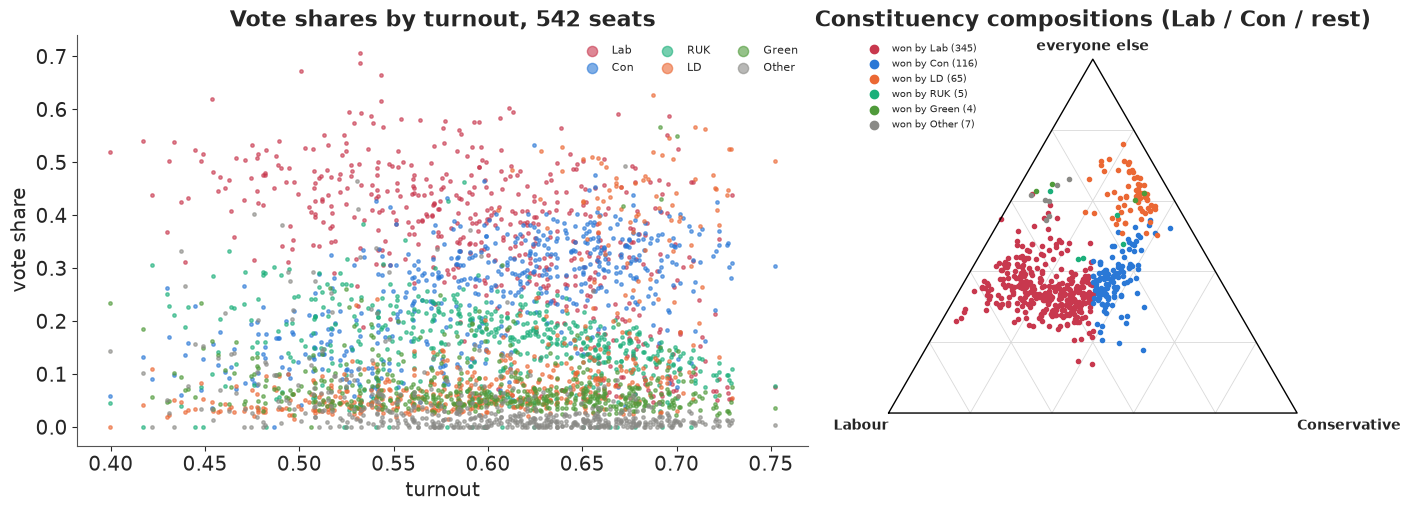

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[1.35, 1])
for p in PARTIES:
    axes[0].scatter(turnout, Sv[:, PARTIES.index(p)], s=6, color=PCOL[p], alpha=0.6, label=p)
axes[0].set(xlabel="turnout", ylabel="vote share", title="Vote shares by turnout, 542 seats")
axes[0].legend(markerscale=3, ncol=3, fontsize=8)
three = np.c_[Sv[:, 0], Sv[:, 1], Sv[:, 2:].sum(axis=1)]
tern_axes(axes[1], ["Labour", "Conservative", "everyone else"])
for p in ["Lab", "Con", "LD", "RUK", "Green", "Other"]:
    m = winner == p
    axes[1].scatter(*tern_xy(three[m]), s=9, color=PCOL[p], label=f"won by {p} ({m.sum()})")
axes[1].legend(loc="upper left", fontsize=7, markerscale=2)
axes[1].set_title("Constituency compositions (Lab / Con / rest)");

Labour's share falls with turnout while Conservative and Liberal Democrat shares rise. The
ternary plot shows the fragmentation of 2024: most seats sit in the middle of the triangle,
with "everyone else" often taking 30-50% of the vote, and Labour winning most seats with
35-50%.

## 5.2 · Zeros break log-ratios

$\log(0)$ is $-\infty$, so the 21 seats without a Reform candidate have no
$\log(\text{RUK}/\text{Lab})$. The common fix is to replace zeros with a small count (half a
vote, say) and carry on. For **structural** zeros this invents data: it claims Reform got
0.001% of the vote where it had no candidate.

sd of log(RUK/Lab): 0.73 where Reform stood, 1.96 with the 0.5-vote replacement (21 seats)


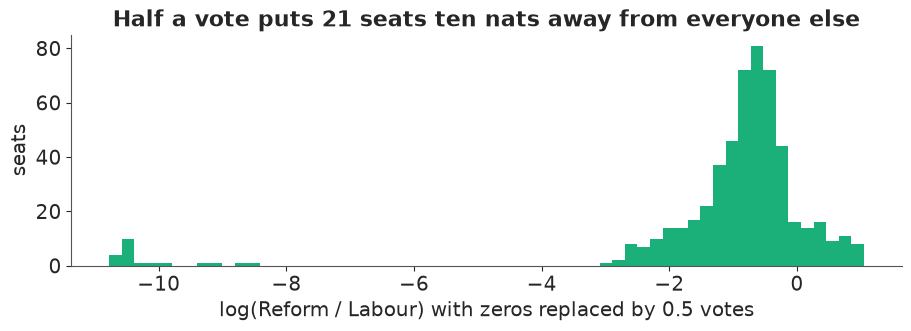

In [18]:
alr_hack = np.log((Yv[:, 2] + 0.5 * (Yv[:, 2] == 0)) / Yv[:, 0])
alr_ok = alr_hack[stand[:, 2]]
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(alr_hack, bins=60, color=AQUA)
ax.set(xlabel="log(Reform / Labour) with zeros replaced by 0.5 votes", ylabel="seats",
       title="Half a vote puts 21 seats ten nats away from everyone else")
print(f"sd of log(RUK/Lab): {alr_ok.std():.2f} where Reform stood, {alr_hack.std():.2f} with the "
      f"0.5-vote replacement ({(~stand[:, 2]).sum()} seats)");

Twenty-one invented observations near $-10$ more than double the apparent spread of
$\log(\text{RUK}/\text{Lab})$, and their exact position depends on the arbitrary constant
(0.5 votes, 1 vote, 0.1 votes...). They would distort every covariance involving Reform.

**What to do instead depends on the kind of zero.**

* A **structural zero** (the part does not exist here: no candidate, a mineral absent from a
  rock type) is handled exactly by **dropping the part** for that observation. The remaining
  parts form a subcomposition, and log-ratios among them are unaffected by the missing part
  (the subcompositional coherence of section 1.3). In a logistic-normal model the density of
  the observed log-ratios is simply the **marginal** MvNormal of those coordinates; in a
  count model the part is removed from the softmax.
* A **sampling zero** (the part exists but none was counted - a rare species in a small
  microbiome read, a rare cell type) is information about a small share. Count models
  (multinomial, Dirichlet-multinomial, logistic-normal-multinomial) handle it naturally:
  a zero count is just a likely outcome when the share is small and the total is modest.

Here all zeros are structural.

## 5.3 · One mean model, three likelihoods

Seat $i$ in region $r[i]$ has five log-ratios against Labour (the reference: it stood
everywhere and never polled below 10%):

$$\eta_i = \alpha_{r[i]} + \beta\, t_i, \qquad \alpha_{r} = \mu + \tau \odot z_r,\;
  z_r \sim N(0, I),$$

with $t_i$ turnout in 10-point steps from 60%. Regional compositions are **partially pooled**
towards the national mean $\mu$ with one between-region scale $\tau_j$ per log-ratio
(non-centred). Priors: $\mu_j \sim N(0, 1.5)$, $\tau_j \sim \text{HalfNormal}(1)$,
$\beta_j \sim N(0, 1)$ per 10 points. Three likelihoods for the votes $Y_i$ (6 counts summing
to the valid vote $n_i$), with absent parts removed:

| model | likelihood | what it assumes |
|---|---|---|
| **M** | $Y_i \sim \text{Multinomial}(n_i, \operatorname{softmax}\eta_i)$ | every voter in the region with this turnout is an independent draw from one composition |
| **DM** | $Y_i \sim \text{DirichletMultinomial}(n_i, \phi\operatorname{softmax}\eta_i)$ | each seat has its own composition, Dirichlet around the mean |
| **LN** | $\text{alr}(Y_i/n_i) \sim \text{MvNormal}(\eta_i, \Sigma)$ | each seat has its own composition, logistic-normal around the mean |

For LN we treat the observed shares as the seat's composition. The counting noise of a
log-ratio, about $\sqrt{1/Y_{ij} + 1/Y_{i,\text{Lab}}}$, is 0.01-0.1 for ordinary shares
(tens of thousands of votes), tiny next to the between-seat scatter of 0.5-1 we will
estimate. With small totals (a microbiome read, a small survey) you would keep the multinomial
layer and make the logistic-normal composition latent.

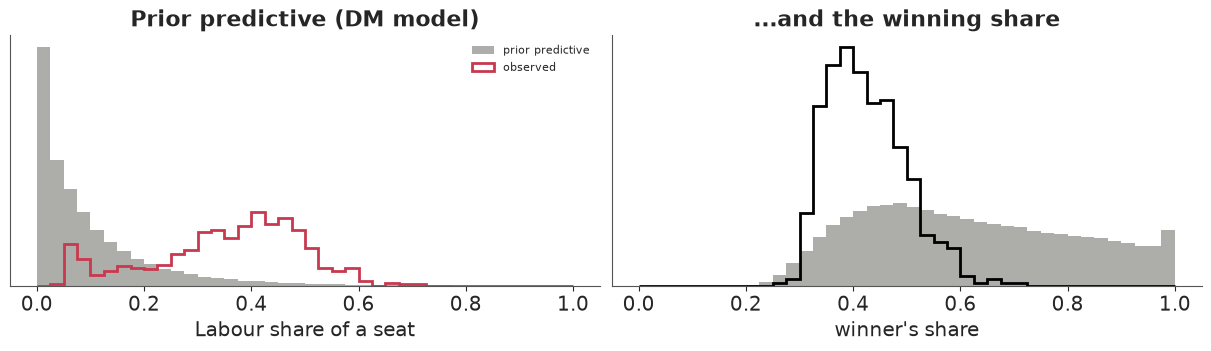

In [19]:
coords_v = {"seat": elec.constituency.to_numpy(dtype=object), "part": PARTIES,
            "ratio": PARTIES[1:], "ratio_": PARTIES[1:], "region": regions}


def mean_model():
    """Regional (partially pooled) + turnout log-ratios vs Labour: (seat, ratio)."""
    mu = pm.Normal("mu", 0, 1.5, dims="ratio")
    tau = pm.HalfNormal("tau", 1.0, dims="ratio")
    z = pm.Normal("z_region", 0, 1, dims=("region", "ratio"))
    a_reg = pm.Deterministic("a_region", mu + tau * z, dims=("region", "ratio"))
    beta = pm.Normal("beta", 0, 1, dims="ratio")
    return a_reg[rid] + beta * tz[:, None]


def softmax_standing(eta_ratio):
    """Composition over the parts that stood: Labour = 0, absent parts get probability 0."""
    eta = pt.concatenate([pt.zeros((Nseat, 1)), eta_ratio], axis=1)
    return pm.math.softmax(pt.where(stand, eta, -np.inf), axis=1)


with pm.Model(coords=coords_v) as m_mult:
    p = softmax_standing(mean_model())
    pm.Multinomial("y", n=nv, p=p, observed=Yv, dims=("seat", "part"))

with pm.Model(coords=coords_v) as m_dm:
    p = softmax_standing(mean_model())
    phi = pm.Gamma("phi", 2, 0.05)
    # absent parts: a tiny concentration with a zero count contributes exactly 0 to the logp
    pm.DirichletMultinomial("y", n=nv, a=pt.where(stand, phi * p, 1e-8), observed=Yv,
                            dims=("seat", "part"))
    prior_dm = pm.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED)

S_prior = draws(prior_dm, "y", "prior_predictive") / nv[None, :, None]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
bins = np.linspace(0, 1, 41)
axes[0].hist(S_prior[..., 0].ravel(), bins=bins, density=True, color=GREY, alpha=0.7,
             label="prior predictive")
axes[0].hist(Sv[:, 0], bins=bins, density=True, histtype="step", color=RED, lw=2, label="observed")
axes[0].set(xlabel="Labour share of a seat", yticks=[], title="Prior predictive (DM model)")
axes[0].legend(fontsize=8)
axes[1].hist(S_prior.max(axis=2).ravel(), bins=bins, density=True, color=GREY, alpha=0.7)
axes[1].hist(Sv.max(axis=1), bins=bins, density=True, histtype="step", color="k", lw=2)
axes[1].set(xlabel="winner's share", yticks=[], title="...and the winning share");

The prior treats the six parts symmetrically, so a typical prior seat gives Labour about a
sixth of the vote and most prior seats give it less than 20%; it also allows landslides
(winning shares near 1) and six-way splits. The observed Labour shares sit in the upper part
of the prior range and the observed winning shares in its lower part - well inside the
support, without the prior concentrating on them. (The prior on $\phi$, Gamma(2, 0.05) with
mean 40, is broad; the data will pin it down.)

---
# 6 · Multinomial vs Dirichlet-multinomial: how many "votes" is a constituency worth?

In [20]:
t0 = time.time()
with m_mult:
    idata_mult = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata_mult, progressbar=False)
fit_report(idata_mult, ["mu", "tau", "beta"], t0)
t0 = time.time()
with m_dm:
    idata_dm = pm.sample(random_seed=RANDOM_SEED, target_accept=0.95, progressbar=False)
    pm.compute_log_likelihood(idata_dm, progressbar=False)
fit_report(idata_dm, ["mu", "tau", "beta", "phi"], t0)
pd.DataFrame({"M: beta": idata_mult.posterior["beta"].mean(("chain", "draw")),
              "M: sd": idata_mult.posterior["beta"].std(("chain", "draw")),
              "DM: beta": idata_dm.posterior["beta"].mean(("chain", "draw")),
              "DM: sd": idata_dm.posterior["beta"].std(("chain", "draw"))},
             index=PARTIES[1:]).round(3)

37 s, max r_hat 1.008, min bulk ESS 451, divergences 0, tuning steps 400


20 s, max r_hat 1.005, min bulk ESS 629, divergences 0, tuning steps 400


,M: beta,M: sd,DM: beta,DM: sd
Con,0.574,0.001,0.617,0.038
RUK,0.060,0.001,0.165,0.040
LD,1.192,0.001,0.939,0.052
Green,0.112,0.001,0.179,0.051
Other,-0.587,0.002,-0.217,0.061


Both samplers converge, and the turnout effects point the same way, but look at the
**posterior standard deviations**: the multinomial is about 30-50 times more certain. It
treats ~25 million votes as 25 million independent draws from nine regional compositions, so
every seat-to-seat difference that turnout does not explain must be pure chance - impossible
with tens of thousands of votes per seat. A posterior predictive check shows how impossible.

We simulate full elections from each model (new compositions and new counts in all 542 seats,
with each seat's region, turnout, total and set of candidates held fixed) and compare the
**within-region spread** of each party's share with the observed spread.

In [21]:
NPP = 400                                                 # posterior draws used for predictions
ppc_rng = np.random.default_rng(RANDOM_SEED)


def mean_eta(idata, idx):
    a_reg = draws(idata, "a_region")[idx]                 # (S, region, ratio)
    beta = draws(idata, "beta")[idx]                      # (S, ratio)
    return a_reg[:, rid] + beta[:, None, :] * tz[None, :, None]   # (S, seat, ratio)


def to_shares(eta_ratio):
    eta = np.concatenate([np.zeros(eta_ratio.shape[:-1] + (1,)), eta_ratio], axis=-1)
    return special.softmax(np.where(stand, eta, -np.inf), axis=-1)


def replicate(idata, kind, n_draws=NPP):
    """Replicated vote counts (S, seat, part) under model M, DM or LN."""
    S_all = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
    idx = ppc_rng.choice(S_all, n_draws, replace=False)
    eta = mean_eta(idata, idx)
    if kind == "M":
        comp = to_shares(eta)
    elif kind == "DM":
        phi = draws(idata, "phi")[idx]
        g = ppc_rng.gamma(np.where(stand, phi[:, None, None] * to_shares(eta), 1.0))
        comp = closure(np.where(stand, g, 0.0))
    else:
        Sig = draws(idata, "Sigma")[idx]
        eps = np.einsum("sij,snj->sni", np.linalg.cholesky(Sig),
                        ppc_rng.standard_normal(eta.shape))
        comp = to_shares(eta + eps)
    return ppc_rng.multinomial(nv[None, :], comp)


def within_region_resid(S):
    """Shares minus their region means (works on (..., seat, part))."""
    out = S.copy()
    for r in range(len(regions)):
        m = rid == r
        out[..., m, :] -= S[..., m, :].mean(axis=-2, keepdims=True)
    return out


def spread(S):
    return within_region_resid(S).std(axis=-2)           # (..., part)


rep = {"M": replicate(idata_mult, "M"), "DM": replicate(idata_dm, "DM")}
sp_obs = spread(Sv)
sp_rep = {k: spread(v / nv[None, :, None]) for k, v in rep.items()}
pd.DataFrame({"observed": sp_obs,
              **{f"{k}: median": np.median(v, axis=0) for k, v in sp_rep.items()},
              **{f"{k}: 90% interval": [f"{lo:.3f}-{hi:.3f}" for lo, hi in
                                        zip(*np.quantile(v, [0.05, 0.95], axis=0))]
                 for k, v in sp_rep.items()}}, index=PARTIES).round(3)

,observed,M: median,DM: median,M: 90% interval,DM: 90% interval
Lab,0.115,0.057,0.111,0.056-0.057,0.105-0.117
Con,0.088,0.047,0.098,0.047-0.047,0.093-0.104
RUK,0.062,0.039,0.082,0.039-0.039,0.077-0.086
LD,0.117,0.058,0.074,0.058-0.058,0.069-0.080
Green,0.054,0.009,0.055,0.009-0.009,0.050-0.059
Other,0.068,0.030,0.043,0.030-0.030,0.039-0.047


Within a region, observed shares have standard deviations of 5-12 percentage points. The
multinomial's replicates vary only through turnout, and every one of its intervals is far
below the observed spread (it gives zero spread to parts turnout hardly moves). The
Dirichlet-multinomial gets the size roughly right for Labour, the Conservatives and the
Greens, but gives Reform too much spread and the Lib Dems and "Other" far too little: one
$\phi$ must serve all parts. LOO says the same in its own units.

In [22]:
loo_mult = az.loo(idata_mult, var_name="y", pointwise=True)
loo_dm = az.loo(idata_dm, var_name="y", pointwise=True)
for nm, lo in [("M", loo_mult), ("DM", loo_dm)]:
    print(f"{nm:>2}: elpd {lo.elpd:12,.0f} (se {lo.se:8,.0f}); Pareto k > 0.7 in "
          f"{int((lo.pareto_k > 0.7).sum())} of {Nseat} seats")
phi_d = draws(idata_dm, "phi")
print(f"DM precision phi: {q(phi_d)}")
print(f"overdispersion factor (n + phi)/(1 + phi) for a seat of 45,000 votes: "
      f"{q((45000 + phi_d) / (1 + phi_d), (0.5,))[0]:,.0f}")

 M: elpd   -2,434,793 (se  139,902); Pareto k > 0.7 in 541 of 542 seats
DM: elpd      -23,846 (se      101); Pareto k > 0.7 in 0 of 542 seats
DM precision phi: [23.   24.15 25.33]
overdispersion factor (n + phi)/(1 + phi) for a seat of 45,000 votes: 1,790


The multinomial's elpd is worse by about 2.4 million nats, and Pareto $k > 0.7$ in 541 of 542
seats says its LOO estimate cannot even be trusted: every seat is a huge surprise to it.

The Dirichlet-multinomial's precision $\phi$ comes out around 24, and it has a vivid reading.
The variance of a share under the DM is the multinomial variance times $(n + \phi)/(1 +
\phi)$, about 1,800 for a seat of 45,000 votes. Equivalently, **for the question "what share
will a party get in a seat like this?", a constituency of 45,000 voters carries about as
much information as a random sample of $\phi + 1 \approx 25$ voters.** The total $n$ is
nearly irrelevant: what varies is the seat's composition, not the counting. Treating the
total "properly" here means recognising that it hardly matters, and it is why the LN model
below may work with shares directly.

## 6.1 · The check the Dirichlet-multinomial fails

The DM draws each seat's composition from a Dirichlet, so it inherits the Dirichlet's
restriction: **all parts are negatively correlated** around the mean. (The correlations of
*replicated* shares within regions also contain the turnout trend, which is why a pair can
still come out slightly positive.) The observed within-region correlations are not all
negative: Labour and Green shares rise together (urban, younger seats), Conservative and
Reform are mildly positive, and Labour and the Lib Dems are strongly negative.

In [23]:
def corr_mat(S):
    """Correlation matrix of within-region residual shares; S: (..., seat, part)."""
    r = within_region_resid(S)
    r = r - r.mean(axis=-2, keepdims=True)
    c = np.einsum("...np,...nq->...pq", r, r)
    d = np.sqrt(np.einsum("...pp->...p", c))
    return c / d[..., :, None] / d[..., None, :]


C_obs = corr_mat(Sv)
C_rep = {k: corr_mat(v / nv[None, :, None]) for k, v in rep.items() if k != "M"}
pairs = [(0, 4, "Lab-Green"), (1, 2, "Con-RUK"), (1, 3, "Con-LD"), (0, 3, "Lab-LD"),
         (0, 1, "Lab-Con")]
for i, j, nm in pairs:
    c = C_rep["DM"][:, i, j]
    print(f"{nm:<10} observed {C_obs[i, j]:+.2f}; DM replicates {q(c)}; "
          f"P(rep >= obs) = {np.mean(c >= C_obs[i, j]):.3f}")

Lab-Green  observed +0.31; DM replicates [-0.2  -0.13 -0.06]; P(rep >= obs) = 0.000
Con-RUK    observed +0.10; DM replicates [-0.36 -0.3  -0.23]; P(rep >= obs) = 0.000
Con-LD     observed +0.10; DM replicates [-0.    0.07  0.14]; P(rep >= obs) = 0.275
Lab-LD     observed -0.73; DM replicates [-0.49 -0.43 -0.38]; P(rep >= obs) = 1.000
Lab-Con    observed -0.49; DM replicates [-0.58 -0.54 -0.48]; P(rep >= obs) = 0.077


The Labour-Green (+0.31) and Conservative-Reform (+0.10) correlations are never reached by
the DM, whose replicates are all negative, and the Labour-Lib Dem correlation (-0.73 observed:
the two replace each other as the anti-Conservative choice) is much stronger than anything the
DM produces. The DM gets the rough *size* of seat-to-seat variation and its *shape* wrong. That
matters for seats: who wins depends on how the parts move *together*.

---
# 7 · The logistic-normal for votes

## 7.1 · Marginalising absent parts

The LN model puts a full $5 \times 5$ covariance on the log-ratios. Seats where a part did not
stand contribute the marginal MvNormal of the log-ratios that exist. There are only a few
**patterns** of absent parts, so we group seats by pattern and write one `MvNormal` per
pattern with the corresponding sub-vector of the mean and sub-matrix of $\Sigma$.

In [24]:
patterns, pat_id = np.unique(stand[:, 1:], axis=0, return_inverse=True)
alr_v = np.log(np.where(stand, Sv, 1.0)[:, 1:] / Sv[:, [0]])   # absent entries are never used
for k, pk in enumerate(patterns):
    print(f"pattern {k}: absent = {[p for p, s in zip(PARTIES[1:], pk) if not s] or 'none'}, "
          f"{np.sum(pat_id == k)} seats")


def build_ln(alr_obs):
    with pm.Model(coords=coords_v) as m:
        eta = mean_model()
        chol, corr, sds = pm.LKJCholeskyCov("chol", n=5, eta=2.0,
                                            sd_dist=pm.Exponential.dist(1.0), compute_corr=True)
        Sigma = pm.Deterministic("Sigma", chol @ chol.T, dims=("ratio", "ratio_"))
        pm.Deterministic("corr", corr, dims=("ratio", "ratio_"))
        pm.Deterministic("s", sds, dims="ratio")
        for k, pk in enumerate(patterns):
            rows, cols = np.where(pat_id == k)[0], np.where(pk)[0]
            pm.MvNormal(f"alr_{k}", mu=eta[rows][:, cols], cov=Sigma[cols][:, cols],
                        observed=alr_obs[rows][:, cols])
    return m


m_lnv = build_ln(alr_v)
t0 = time.time()
with m_lnv:
    idata_lnv = pm.sample(random_seed=RANDOM_SEED, target_accept=0.95, progressbar=False)
fit_report(idata_lnv, ["mu", "tau", "beta", "s", "chol"], t0)
az.summary(idata_lnv, var_names=["s"], round_to=3)

pattern 0: absent = ['Con'], 1 seats
pattern 1: absent = ['RUK'], 21 seats
pattern 2: absent = ['LD'], 1 seats
pattern 3: absent = ['Green'], 1 seats
pattern 4: absent = ['Other'], 78 seats
pattern 5: absent = none, 440 seats


11 s, max r_hat 1.011, min bulk ESS 639, divergences 0, tuning steps 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
s[Con],0.642,0.020,0.611,0.675,4005.956,3245.665,1.000,0.0,0.000
s[RUK],0.581,0.018,0.553,0.610,4167.764,3127.337,1.000,0.0,0.000
s[LD],0.967,0.030,0.921,1.015,4471.091,3372.927,1.000,0.0,0.000
s[Green],0.516,0.016,0.491,0.542,6570.471,2843.061,1.000,0.0,0.000
s[Other],1.115,0.037,1.057,1.176,5999.700,3089.939,1.004,0.0,0.001


within-region spread, observed vs LN replicates (median, 90%):
  Lab    0.115  LN [0.12 0.13 0.14]  DM [0.1  0.11 0.12]
  Con    0.088  LN [0.1  0.1  0.11]  DM [0.09 0.1  0.1 ]
  RUK    0.062  LN [0.06 0.06 0.07]  DM [0.08 0.08 0.09]
  LD     0.117  LN [0.08 0.09 0.1 ]  DM [0.07 0.07 0.08]
  Green  0.054  LN [0.04 0.04 0.04]  DM [0.05 0.05 0.06]
  Other  0.068  LN [0.04 0.05 0.07]  DM [0.04 0.04 0.05]
Lab-Green  observed +0.31; LN [0.19 0.27 0.35]; DM [-0.2  -0.13 -0.06]
Con-RUK    observed +0.10; LN [0.01 0.1  0.18]; DM [-0.36 -0.3  -0.23]
Con-LD     observed +0.10; LN [-0.03  0.05  0.13]; DM [-0.    0.07  0.14]
Lab-LD     observed -0.73; LN [-0.63 -0.58 -0.54]; DM [-0.49 -0.43 -0.38]
Lab-Con    observed -0.49; LN [-0.69 -0.63 -0.57]; DM [-0.58 -0.54 -0.48]


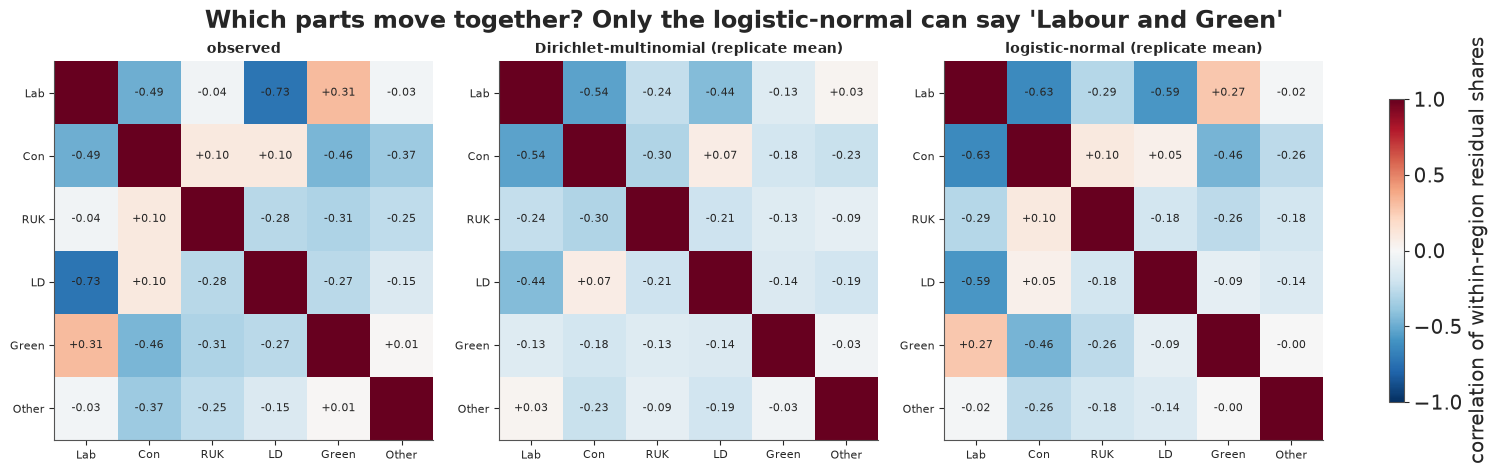

In [25]:
rep["LN"] = replicate(idata_lnv, "LN")
sp_rep["LN"] = spread(rep["LN"] / nv[None, :, None])
C_rep["LN"] = corr_mat(rep["LN"] / nv[None, :, None])
print("within-region spread, observed vs LN replicates (median, 90%):")
for k, p in enumerate(PARTIES):
    print(f"  {p:<6} {sp_obs[k]:.3f}  LN {q(sp_rep['LN'][:, k])}  DM {q(sp_rep['DM'][:, k])}")
for i, j, nm in pairs:
    print(f"{nm:<10} observed {C_obs[i, j]:+.2f}; LN {q(C_rep['LN'][:, i, j])}; "
          f"DM {q(C_rep['DM'][:, i, j])}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (title, C) in zip(axes, [("observed", C_obs),
                                 ("Dirichlet-multinomial (replicate mean)", C_rep["DM"].mean(0)),
                                 ("logistic-normal (replicate mean)", C_rep["LN"].mean(0))]):
    im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
    for i in range(6):
        for j in range(6):
            if i != j:
                ax.text(j, i, f"{C[i, j]:+.2f}", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(6), PARTIES, fontsize=8)
    ax.set_yticks(range(6), PARTIES, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="correlation of within-region residual shares")
fig.suptitle("Which parts move together? Only the logistic-normal can say 'Labour and Green'");

The logistic-normal reproduces the *pattern* of the observed correlation matrix: the
positive Labour-Green and Conservative-Reform pairs, the negative Conservative-Green pair and
a strong Labour-Lib Dem trade-off. The DM's matrix is mildly negative almost everywhere. The
LN is not perfect: its Labour-Lib Dem correlation (about -0.6) is still weaker than the
observed -0.73, its Labour-Conservative correlation too strong, and it gives the Lib Dems too
little spread (0.08-0.10 against 0.117) and Labour and the Conservatives slightly too much.
Remember this Lib Dem shortfall; it will matter for seats.

The estimated log-ratio scales $s_j$ are the between-seat standard deviations of
$\log(\text{part}/\text{Labour})$ after region and turnout: about 0.5-0.65 for the
Conservatives, Reform and the Greens, about 1 for the Lib Dems and 1.1 for Other, whose share
ranges from a few hundred votes to seat-winning independents.

## 7.2 · Known-truth check: can this model recover a correlation structure with absent parts?

**Simulated data.** The marginalisation code is exactly the kind of thing that can be subtly
wrong (a transposed index silently mismatches a pattern's columns). So we simulate one
election from the model with *known* parameters - the posterior means - using the
real regions, turnouts and pattern of absent parts, fit it with the same code, and check
that the intervals cover the truth.

9 s, max r_hat 1.008, min bulk ESS 488, divergences 0, tuning steps 400


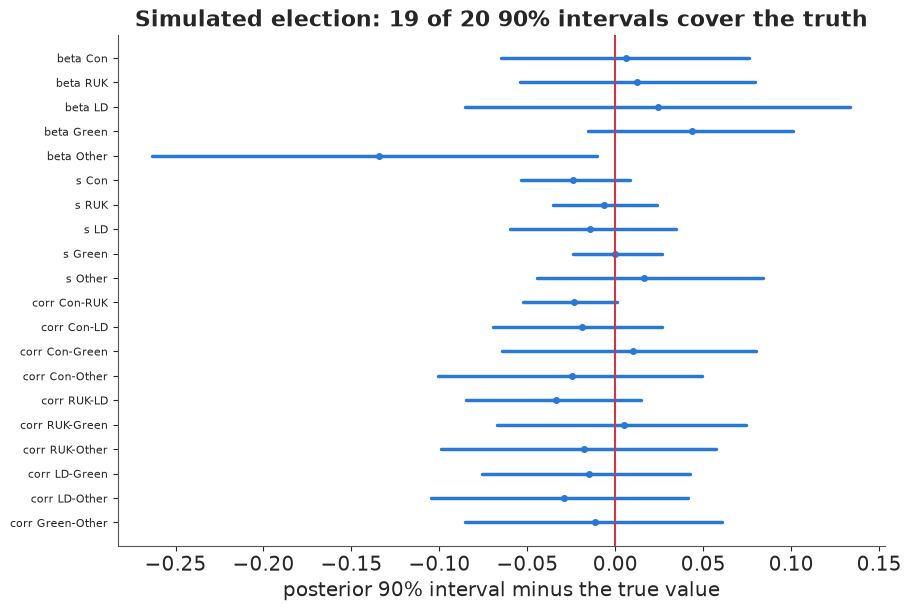

In [26]:
truth = {v: idata_lnv.posterior[v].mean(("chain", "draw")).to_numpy()
         for v in ["a_region", "beta", "Sigma"]}
Ls = np.linalg.cholesky(truth["Sigma"])
eta_true = truth["a_region"][rid] + truth["beta"] * tz[:, None]
alr_sim = eta_true + rng.standard_normal((Nseat, 5)) @ Ls.T
alr_sim = np.where(stand[:, 1:], alr_sim, 0.0)                  # absent parts are never seen

t0 = time.time()
with build_ln(alr_sim):
    idata_sim = pm.sample(random_seed=RANDOM_SEED, target_accept=0.95, progressbar=False)
fit_report(idata_sim, ["mu", "tau", "beta", "s", "chol"], t0)

C_true = truth["Sigma"] / np.sqrt(np.outer(np.diag(truth["Sigma"]), np.diag(truth["Sigma"])))
iu = np.triu_indices(5, 1)
checks = [("beta " + p, truth["beta"][k], draws(idata_sim, "beta")[:, k])
          for k, p in enumerate(PARTIES[1:])]
checks += [(f"s {p}", np.sqrt(truth["Sigma"][k, k]), draws(idata_sim, "s")[:, k])
           for k, p in enumerate(PARTIES[1:])]
checks += [(f"corr {PARTIES[1 + i]}-{PARTIES[1 + j]}", C_true[i, j],
            draws(idata_sim, "corr")[:, i, j]) for i, j in zip(*iu)]
fig, ax = plt.subplots(figsize=(9, 6))
covered = 0
for k, (nm, tv, d) in enumerate(checks):
    lo, hi = np.quantile(d, [0.05, 0.95])
    covered += lo <= tv <= hi
    ax.plot([lo - tv, hi - tv], [k, k], color=BLUE, lw=2.5)
    ax.plot(np.median(d) - tv, k, "o", color=BLUE, ms=4)
ax.axvline(0, color=RED, lw=1.5)
ax.set_yticks(range(len(checks)), [c[0] for c in checks], fontsize=8)
ax.invert_yaxis()
ax.set(xlabel="posterior 90% interval minus the true value",
       title=f"Simulated election: {covered} of {len(checks)} 90% intervals cover the truth");
del idata_sim

The simulated-data fit recovers the scales and all ten correlations within a few hundredths,
and the turnout effects; one interval of twenty (the turnout effect of Other, the noisiest
part) misses the truth, in line with what 90% intervals should do. The code marginalising
absent parts does what it should.

---
# 8 · From compositions to seats

## 8.1 · Turnout effects, reference-free

Which parts gain in high-turnout seats? As for the sediments, the reference-free answer is the
CLR effect: each party's log share relative to the geometric mean of all six, per 10 points of
turnout.

Lab    CLR effect per +10 points turnout [-0.33 -0.28 -0.23] (x0.76 relative to the geometric mean)
Con    CLR effect per +10 points turnout [0.38 0.43 0.49] (x1.54 relative to the geometric mean)
RUK    CLR effect per +10 points turnout [-0.11 -0.07 -0.02] (x0.94 relative to the geometric mean)
LD     CLR effect per +10 points turnout [0.61 0.68 0.76] (x1.98 relative to the geometric mean)
Green  CLR effect per +10 points turnout [-0.15 -0.09 -0.03] (x0.91 relative to the geometric mean)
Other  CLR effect per +10 points turnout [-0.79 -0.68 -0.58] (x0.51 relative to the geometric mean)


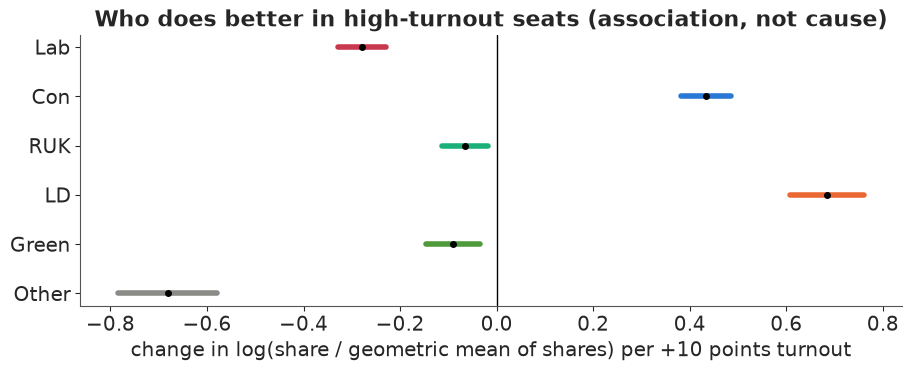

In [27]:
beta_ln = draws(idata_lnv, "beta")
beta_full = np.c_[np.zeros(len(beta_ln)), beta_ln]
beta_clr = beta_full - beta_full.mean(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(9, 3.6))
for k, p in enumerate(PARTIES):
    lo, med, hi = np.quantile(beta_clr[:, k], [0.05, 0.5, 0.95])
    ax.plot([lo, hi], [k, k], color=PCOL[p], lw=4)
    ax.plot(med, k, "o", color="k", ms=4)
    print(f"{p:<6} CLR effect per +10 points turnout {q(beta_clr[:, k])} "
          f"(x{np.exp(med):.2f} relative to the geometric mean)")
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(6), PARTIES)
ax.invert_yaxis()
ax.set(xlabel="change in log(share / geometric mean of shares) per +10 points turnout",
       title="Who does better in high-turnout seats (association, not cause)");

In high-turnout seats the Liberal Democrats (about x2 per 10 points, relative to the
geometric mean) and Conservatives (x1.5) gain, and "Other" (x0.5) and Labour (x0.76) lose;
Reform and the Greens barely move. Because turnout marks affluent, older, more rural seats,
this is a map of the electorate, not an effect of turnout itself.

## 8.2 · Seats: the check that matters for the decision

First-past-the-post turns compositions into seats through the **largest part** in each seat,
which depends on the joint behaviour of the parts. So a natural check - and a natural product
for anyone planning a campaign - is: if we re-ran the election in seats with the same regions,
turnouts and candidates, how many would each party win under each model? (This is a
posterior predictive check: the models know each seat's region and turnout but not its
result.)

In [28]:
seats_obs = np.array([(winner == p).sum() for p in PARTIES])
seat_rep = {k: np.stack([(v.argmax(axis=2) == j).sum(axis=1) for j in range(6)], axis=1)
            for k, v in rep.items()}
tab = pd.DataFrame({"actual": seats_obs}, index=PARTIES)
for k, v in seat_rep.items():
    tab[f"{k}: median"] = np.median(v, axis=0).astype(int)
    tab[f"{k}: 90%"] = [f"{lo:.0f}-{hi:.0f}" for lo, hi in zip(*np.quantile(v, [0.05, 0.95], axis=0))]
tab

,actual,M: median,M: 90%,DM: median,DM: 90%,LN: median,LN: 90%
Lab,345,364,362-365,317,300-334,317,299-336
Con,116,154,152-157,164,146-181,169,150-187
RUK,5,0,0-0,32,23-43,12,6-18
LD,65,24,22-25,25,17-34,40,29-52
Green,4,0,0-0,2,0-5,0,0-1
Other,7,0,0-0,0,0-2,4,1-8


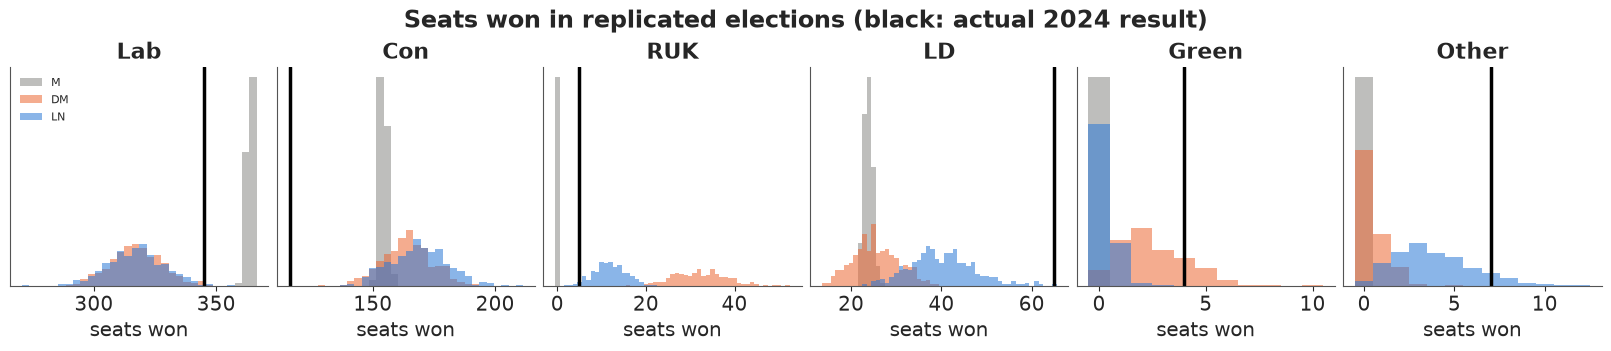

In [29]:
fig, axes = plt.subplots(1, 6, figsize=(16, 3.4))
for k, (ax, p) in enumerate(zip(axes, PARTIES)):
    lo = min(min(seat_rep[m][:, k].min() for m in seat_rep), seats_obs[k])
    hi = max(max(seat_rep[m][:, k].max() for m in seat_rep), seats_obs[k])
    bins = np.arange(lo - 0.5, hi + 1.5, max(1, (hi - lo) // 30))
    for m, c in zip(["M", "DM", "LN"], [GREY, ORANGE, BLUE]):
        ax.hist(seat_rep[m][:, k], bins=bins, color=c, alpha=0.55, label=m)
    ax.axvline(seats_obs[k], color="k", lw=2.5)
    ax.set(title=p, yticks=[], xlabel="seats won")
axes[0].legend(fontsize=8)
fig.suptitle("Seats won in replicated elections (black: actual 2024 result)");

Read the table and the figure party by party:

* The **multinomial** gives every seat its regional-average composition (adjusted for
  turnout), so it hands almost every seat to whoever leads that average: too many for Labour
  and the Conservatives, a third of the actual Lib Dem seats, and never a seat for Reform,
  the Greens or Other.
* The **Dirichlet-multinomial** spreads compositions out, so smaller parties win some seats -
  but the wrong ones: it gives Reform 23-43 seats (actual 5), because it gives Reform's share
  too much seat-to-seat spread, and still far too few to the Lib Dems.
* The **logistic-normal** gets Reform and Other about right and gives the Lib Dems more seats,
  but **all three models miss the same way**: too many Conservative seats (about 150-190
  against 116), too few Lib Dem seats (at most about 50 against 65) and a few too few Labour
  seats.

That shared miss is the signature of **tactical anti-Conservative voting**: in each seat,
the Labour and Lib Dem votes concentrate behind whichever of them is the local challenger.
The result is a Lib Dem share that is *bimodal* across seats - a few percent in most seats,
35-50% where they are the challenger - which no unimodal model centred on region and turnout
can produce.

seats with Lib Dem ahead of Labour      observed  85, LN replicates (5%, 50%, 95%) [ 72.    86.   102.05]
seats with Lib Dem more than 3x Labour  observed  55, LN replicates (5%, 50%, 95%) [ 9.95 17.   24.  ]


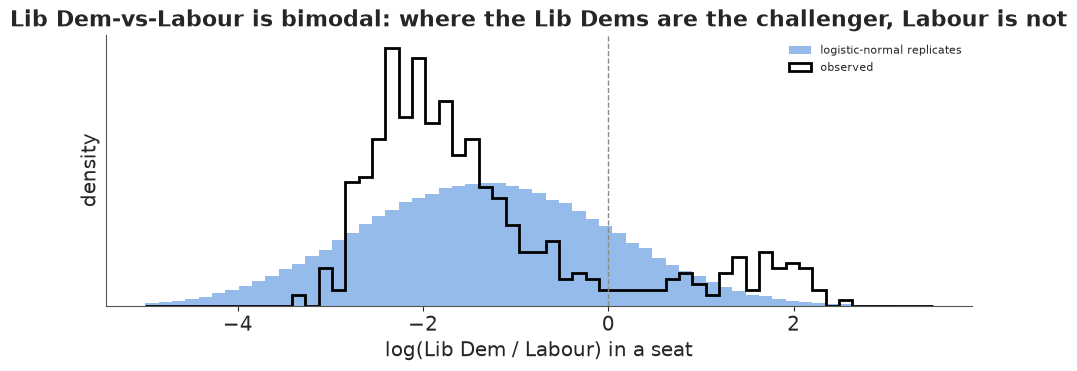

In [30]:
lr_obs = np.log(np.where(stand[:, 3], Sv[:, 3], 1.0) / Sv[:, 0])
lr_rep = np.log(np.clip(rep["LN"][..., 3], 1, None) / rep["LN"][..., 0])
fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(-5, 3.5, 60)
ax.hist(lr_rep[:, stand[:, 3]].ravel(), bins=bins, density=True, color=BLUE, alpha=0.5,
        label="logistic-normal replicates")
ax.hist(lr_obs[stand[:, 3]], bins=bins, density=True, histtype="step", color="k", lw=2,
        label="observed")
ax.axvline(0, color=GREY, lw=1, ls="--")
ax.set(xlabel="log(Lib Dem / Labour) in a seat", ylabel="density", yticks=[],
       title="Lib Dem-vs-Labour is bimodal: where the Lib Dems are the challenger, Labour is not")
ax.legend(fontsize=8)
for cut, lab in [(0.0, "Lib Dem ahead of Labour"), (np.log(3), "Lib Dem more than 3x Labour")]:
    print(f"seats with {lab:<28} observed {np.sum(lr_obs[stand[:, 3]] > cut):>3}, LN replicates "
          f"(5%, 50%, 95%) {q(np.sum(lr_rep[:, stand[:, 3]] > cut, axis=1))}")

The observed distribution has a second mode where the Lib Dems are far ahead of Labour
(Labour squeezed to a few percent). The logistic-normal spreads the mass into one wide hump:
it gets the *number* of seats where the Lib Dems lead Labour about right (85 observed), but
most of them sit in the valley between the modes (a narrow Lib Dem lead, Labour still
sizeable). Seats where the Lib Dems have more than three times Labour's vote - Labour squeezed
- number 55 in reality and only about 10-24 in the replicates, and those are exactly the seats
in which the Lib Dems beat the Conservatives. Heavier tails would not create a second mode. What would help is
information the model does not have: **which seats are Lib Dem targets** - their previous
result, which is not in this file (the 2024 boundaries are new). This is a useful lesson in
its own right: the logistic-normal passed its correlation check and still fails the check
that matters for the decision, so the seat-level answers below come with that caveat.

## 8.3 · A decision question: who is favourite in a seat like this?

A party strategist (or a bookmaker, or a newsroom) wants, for a seat with a given region and
turnout but otherwise unknown, the probability that each party wins. This is the posterior
predictive distribution of the winner for a new seat with all six parts standing, as a
function of turnout, in three contrasting regions.

,region,turnout,Lab,Con,RUK,LD,Green,Other
0,North West,0.55,0.91,0.04,0.03,0.01,0.0,0.01
1,North West,0.65,0.72,0.19,0.01,0.07,0.0,0.00
2,South East,0.55,0.63,0.27,0.05,0.04,0.0,0.01
3,South East,0.65,0.27,0.56,0.01,0.16,0.0,0.00
4,South West,0.55,0.67,0.19,0.06,0.07,0.0,0.01
5,South West,0.65,0.29,0.49,0.01,0.21,0.0,0.01


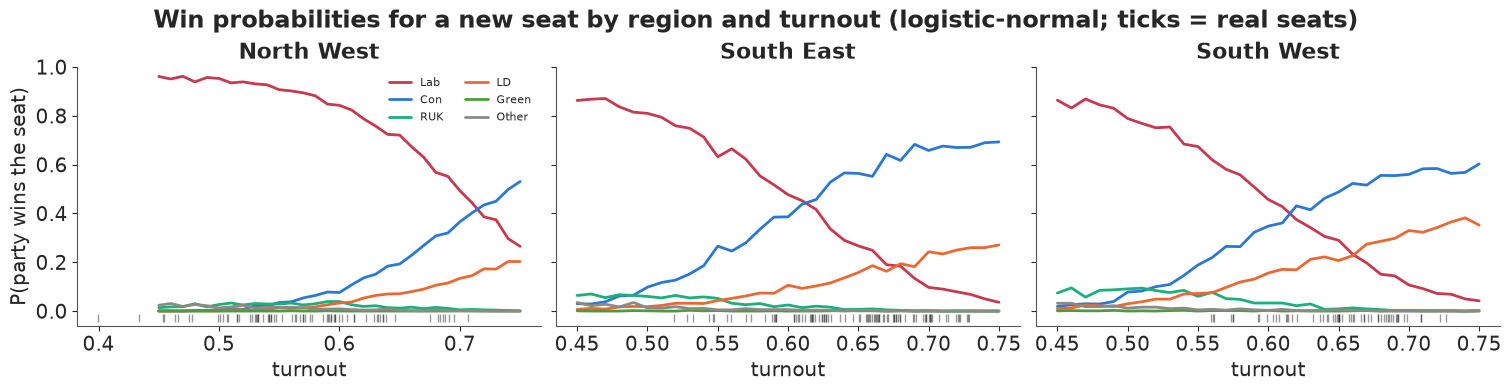

In [31]:
t_grid = np.linspace(0.45, 0.75, 31)
show_regions = ["North West", "South East", "South West"]
S_all = idata_lnv.posterior.sizes["chain"] * idata_lnv.posterior.sizes["draw"]
idx = ppc_rng.choice(S_all, 1000, replace=False)
a_reg, beta_s = draws(idata_lnv, "a_region")[idx], draws(idata_lnv, "beta")[idx]
Lc = np.linalg.cholesky(draws(idata_lnv, "Sigma")[idx])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
win_rows = []
for ax, rname in zip(axes, show_regions):
    r = list(regions).index(rname)
    eta = a_reg[:, None, r, :] + beta_s[:, None, :] * ((t_grid - 0.60) / 0.10)[None, :, None]
    eps = np.einsum("sij,sgj->sgi", Lc, ppc_rng.standard_normal(eta.shape))
    comp = special.softmax(np.concatenate([np.zeros(eta.shape[:-1] + (1,)), eta + eps], -1), -1)
    pwin = np.stack([(comp.argmax(-1) == j).mean(0) for j in range(6)], axis=1)   # (grid, part)
    for j, p in enumerate(PARTIES):
        ax.plot(t_grid, pwin[:, j], color=PCOL[p], lw=2, label=p)
    real = rid == r
    ax.plot(turnout[real], np.full(real.sum(), -0.03), "|", color="k", alpha=0.4)
    ax.set(title=rname, xlabel="turnout", ylim=(-0.06, 1))
    for tv in [0.55, 0.65]:
        g = np.argmin(np.abs(t_grid - tv))
        win_rows.append({"region": rname, "turnout": tv,
                         **{p: round(float(pwin[g, j]), 2) for j, p in enumerate(PARTIES)}})
axes[0].set_ylabel("P(party wins the seat)")
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Win probabilities for a new seat by region and turnout (logistic-normal; ticks = real seats)");
pd.DataFrame(win_rows)

In all three regions Labour is the favourite in low-turnout seats and the Conservatives in the
highest-turnout ones; what differs is where the switch happens. In the North West Labour stays
ahead up to about 72% turnout; in the South East and the South West the Conservatives take
over at about 61-62%, and the Lib Dems become real contenders in high-turnout seats (a win
probability of about 0.25 in the South East and 0.35 in the South West at 70-75%). These probabilities carry both kinds of uncertainty:
about the regional means and turnout effects (small, with 542 seats) and about where an
individual seat falls around them (large - a seat's region and turnout say only so much).
Section 8.2 says how to read them: the model under-produces Lib Dem wins and over-produces
Conservative ones, so the Lib Dem curves are too low and the Conservative ones too high in
seats like the Lib Dems' targets. A strategist would add what they know about the seat itself
- its previous result, its candidates - which is exactly the information the model lacks.

## 8.4 · What the regional pooling did

Nine regions with 26-75 seats each is plenty of data per region, so we expect only slight
shrinkage of the regional means; the between-region scales $\tau$ are the interesting part:
how much regions differ in each log-ratio once turnout is accounted for.

In [32]:
az.summary(idata_lnv, var_names=["tau"], round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau[Con],0.368,0.119,0.227,0.571,860.644,1230.600,1.005,0.004,0.005
tau[RUK],0.440,0.135,0.274,0.677,750.686,1063.024,1.007,0.005,0.005
tau[LD],0.480,0.152,0.296,0.757,962.067,1190.747,1.004,0.005,0.005
tau[Green],0.263,0.085,0.158,0.414,1257.186,1672.516,1.001,0.002,0.002
tau[Other],0.097,0.080,0.008,0.240,1186.394,1566.574,1.002,0.002,0.002


Regions differ most in the Lib Dem, Reform and Conservative log-ratios against Labour
($\tau \approx$ 0.37-0.48), less for the Greens (about 0.26), and hardly at all for "Other"
(about 0.1, with an interval reaching almost 0): once turnout is known, the other-party vote is
no more regional than chance.

## Honest limits

* **Turnout is the only seat covariate.** Real election models use the previous result (not
  in this file; the 2024 boundaries are new, so it would have to be a notional 2019 result),
  demographics and candidate effects. The seat-level scatter here is therefore large, and the
  win probabilities of 8.3 are for "a seat about which you know only its region and turnout".
* **One unimodal Gaussian for all seats.** Tactical voting makes the Lib Dem-vs-Labour
  log-ratio bimodal (8.2), and "Other" mixes minor candidates with a handful of strong
  independents; the seat counts show the cost.
* **The sediments are 39 samples.** The logistic-normal's covariance is estimated from few
  points and the 150 m prediction is an extrapolation of a log-linear trend.

## Summary

* **Compositional data carry relative information only.** Ordinary regression on shares
  predicts negative sand and clay within a factor of two of the sampled depths; raw-share
  correlations change sign when a part is dropped (closure).
* **Log-ratios** (ALR, CLR, ILR) map the simplex to ordinary space; a softmax of a linear
  predictor always gives a valid composition; the ALR reference part changes the meaning of
  coefficients but not the fit of a full-covariance model; report reference-free **CLR effects**.
* **Dirichlet regression** (mean-precision) is a sound first model, but every Dirichlet has
  only negative correlations and one precision, which makes small parts erratic on the log
  scale. The sediments show the opposite (deep-water samples, with little sand, are the most
  uniform), a check the Dirichlet fails in both directions; a **logistic-normal** with an
  **LKJ** covariance whose scale changes with depth passes it and leads on LOO - once all
  densities are on the share scale (add the Jacobian $-\sum \log x_j$).
* **Counts**: a multinomial treats 45,000 votes as 45,000 independent draws and is absurdly
  overconfident; the **Dirichlet-multinomial**'s $\phi \approx 24$ says a constituency is worth
  about 25 votes of information about its composition. The DM still inherits the Dirichlet's
  negative correlations and gets the seat-level trade-offs wrong.
* **Zeros**: replacing structural zeros with half a vote invents extreme observations;
  dropping the absent part (a marginal MvNormal of the remaining log-ratios, or removing it
  from the softmax) is exact. Count models absorb sampling zeros naturally.
* **Decisions** from a composition model depend on how parts move together: seat counts and
  win probabilities come from the joint distribution. The logistic-normal gets the pairwise
  structure closest, but all three models give too many Conservative and too few Lib Dem
  seats: tactical voting makes the Lib Dem share bimodal, which only seat-level information
  (previous results) could capture. Check models on the quantity you will decide with.

## Try it yourself

1. **Challenger seats as a mixture.** Section 8.2 blamed a bimodal Lib Dem share. Model each
   seat as one of two classes - "Lib Dem challenger" or not - with a shifted mean for
   $\log(\text{LD}/\text{Lab})$ and $\log(\text{Con}/\text{Lab})$ in the first class,
   marginalised with `pt.logaddexp` inside a `pm.Potential` per absent-part pattern (use
   `pm.logp(pm.MvNormal.dist(...), value)`). Watch r_hat: the classes are weakly identified
   by region and turnout alone. Do the Lib Dem and Conservative seat counts move towards the
   actual ones?
2. **A depth-dependent precision for the sediments.** Give the Dirichlet regression
   $\log\phi_i = c_0 + c_1 x_i$. Can a Dirichlet whose precision grows with depth pass the
   $T_{shallow}$ / $T_{deep}$ check of section 3.2, given that its log-scale scatter of sand
   is $\psi_1(\phi_i\mu_{i,\text{sand}}) - \psi_1(\phi_i)$? How does it do on LOO against
   the depth-varying logistic-normal?
3. **Small totals.** Thin the election counts to 50 voters per seat
   (`rng.multivariate_hypergeometric` per seat) to mimic a survey or a sequencing read with
   sampling zeros, and fit a **logistic-normal-multinomial** (latent seat log-ratios with the
   LN prior, `pm.Multinomial` on the thinned counts). How much wider are the regional
   compositions, and what happens if you instead drop zeros or add 0.5 to them?